# NeuroModerator v0.1


**Program description**

The program is designed to simplify moderation of public chats and comments. It consists of models trained with classical machine learning methods to recognize four types of messages:

1. INSULT — messages containing insults
2. THREAT — messages containing threats
3. OBSCENITY — messages with sexual or obscene content
4. NORMAL — messages without violations

After analyzing a message, NeuroModerator assigns one or several labels (a multi-label prediction), which can significantly reduce the workload for moderators or automate the moderation process.


**Materials used**

1. alexandersemiletov/toxic-russian-comments — the main dataset of Russian comments. It contains four primary labels. Multi-label examples are present.

2. reihanenamdari/youtube-toxicity-data — an additional dataset from the English-speaking YouTube segment.

3. jahangirhussen/toxic-comment — an additional English-language dataset from social media.

4. ilyaxin/Russian-Swear-Words — a dataset that represents a dictionary of Russian swear words.


**Machine learning algorithms used**

1. XGBoost is an optimized implementation of gradient boosting over decision trees. It is an ensemble method that sequentially builds many weak models (shallow trees), where each subsequent model corrects the errors of the previous ones.

2. LightGBM (Light Gradient Boosting Machine) is a high-performance machine learning library based on gradient boosting over decision trees.

3. Linear SVC is a linear classification method based on support vector machines (SVM, Support Vector Machine), but optimized specifically for linearly separable or nearly linearly separable data. It can be viewed as a simplified and often more efficient version of SVM when the boundary between classes can be represented by a straight line (or a hyperplane in a multidimensional space).

4. MLP (Multi-Layer Perceptron) is a fundamental type of feedforward artificial neural network that underlies deep learning.


**Why not simply use an off-the-shelf model?**

Using a ready-made pretrained model (for example, BERT/RuBERT/Detoxify) does not solve this task correctly for the following reasons:

1. Ready-made models are trained on news, Wikipedia, formal texts, and cleaned corpora. A model may show high metrics on “clean” tests but fail on real user-generated data. Our data is fundamentally different: training is based on user comments and conversational language with slang.

2. Ready-made models are often binary (toxic / non-toxic) or use a different label system. They are not optimized for multi-label classification and do not handle overlapping classes correctly. In this project, multi-label classification is used with independent labels (INSULT, THREAT, OBSCENITY, NORMAL), and one text may have several labels at once.

3. A pretrained model is a black box. It is unclear which patterns it has learned, it is difficult to understand why a specific decision was made, and it is also difficult to calibrate thresholds for each label. In our approach, each label is a separate binary classifier. This makes it possible to analyze errors, adjust weights, tune the threshold (probability cutoff), and fine-tune behavior for a specific label. The approach is much more interpretable and controllable.

4. Computational constraints also matter. Ready-made models require a GPU, are slow at inference (model execution on new data), and scale poorly. Our models are fast, can run on CPU, and are suitable for production scenarios with limited resources. The GPU is used only for translation.


# NOTE

If you want to run this code locally in Jupyter Notebook, make sure you have 32+ GB of RAM and that the swap file is either managed dynamically or set to 32+ GB. Select the CUDA version according to your video card (I used CUDA 13.0).

**Runtime environment configuration**

```
**Name**                  **Version**          **Build**        **Channel**
accelerate                 1.12.0              pypi_0           pypi
aiohappyeyeballs           2.6.1               pypi_0           pypi
aiohttp                    3.13.3              pypi_0           pypi
aiosignal                  1.4.0               pypi_0           pypi
anyio                      4.12.1              pypi_0           pypi
asttokens                  3.0.1               pypi_0           pypi
async-timeout              5.0.1               pypi_0           pypi
attrs                      25.4.0              pypi_0           pypi
blas                       1.0                 mkl
bleach                     6.3.0               pypi_0           pypi
brotlicffi                 1.2.0.0             py310h885b0b7_0
bzip2                      1.0.8               h2bbff1b_6
ca-certificates            2025.12.2           haa95532_0
certifi                    2026.01.04          py310haa95532_0
cffi                       2.0.0               py310h02ab6af_1
charset-normalizer         3.4.4               py310haa95532_0
click                      8.3.1               pypi_0           pypi
colorama                   0.4.6               pypi_0           pypi
comm                       0.2.3               pypi_0           pypi
contourpy                  1.3.2               pypi_0           pypi
cuda-cccl                  13.1.115            h415d894_0       nvidia
cuda-cccl_win-64           13.1.115            hc667259_0       nvidia
cuda-cudart                11.8.89             0                nvidia
cuda-cudart-dev            11.8.89             0                nvidia
cuda-cupti                 11.8.87             0                nvidia
cuda-libraries             11.8.0              0                nvidia
cuda-libraries-dev         11.8.0              0                nvidia
cuda-nvrtc                 11.8.89             0                nvidia
cuda-nvrtc-dev             11.8.89             0                nvidia
cuda-nvtx                  11.8.86             0                nvidia
cuda-profiler-api          13.1.115            h415d894_0       nvidia
cuda-runtime               11.8.0              0                nvidia
cuda-version               13.1                hd92462c_3       nvidia
cycler                     0.12.1              pypi_0           pypi
datasets                   4.4.2               pypi_0           pypi
dawg-python                0.7.2               pypi_0           pypi
debugpy                    1.8.19              pypi_0           pypi
decorator                  5.2.1               pypi_0           pypi
dill                       0.4.0               pypi_0           pypi
docopt                     0.6.2               pypi_0           pypi
exceptiongroup             1.3.1               pypi_0           pypi
executing                  2.2.1               pypi_0           pypi
expat                      2.7.3               h885b0b7_4
filelock                   3.20.0              py310haa95532_0
fonttools                  4.61.1              pypi_0           pypi
freetype                   2.13.3              h0620614_0
frozenlist                 1.8.0               pypi_0           pypi
fsspec                     2025.10.0           pypi_0           pypi
giflib                     5.2.2               h7edc060_0
gmp                        6.3.0               h537511b_0
gmpy2                      2.2.2               py310h8598115_0
h11                        0.16.0              pypi_0           pypi
hf-xet                     1.2.0               pypi_0           pypi
httpcore                   1.0.9               pypi_0           pypi
httpx                      0.28.1              pypi_0           pypi
huggingface-hub            0.36.0              pypi_0           pypi
idna                       3.11                py310haa95532_0
intel-openmp               2023.1.0            h59b6b97_46320
ipykernel                  7.1.0               pypi_0           pypi
ipython                    8.38.0              pypi_0           pypi
ipywidgets                 8.1.8               pypi_0           pypi
jedi                       0.19.2              pypi_0           pypi
jinja2                     3.1.6               py310haa95532_0
joblib                     1.5.3               pypi_0           pypi
jpeg                       9f                  ha349fce_0
jupyter-client             8.8.0               pypi_0           pypi
jupyter-core               5.9.1               pypi_0           pypi
jupyterlab-widgets         3.0.16              pypi_0           pypi
kagglehub                  0.4.0               pypi_0           pypi
kagglesdk                  0.1.14              pypi_0           pypi
kiwisolver                 1.4.9               pypi_0           pypi
lcms2                      2.16                hb4a4139_0
lerc                       3.0                 hd77b12b_0
libcublas                  11.11.3.6           0                nvidia
libcublas-dev              11.11.3.6           0                nvidia
libcufft                   10.9.0.58           0                nvidia
libcufft-dev               10.9.0.58           0                nvidia
libcurand                  10.4.1.81           hd7d98ca_0       nvidia
libcurand-dev              10.4.1.81           hd7d98ca_0       nvidia
libcusolver                11.4.1.48           0                nvidia
libcusolver-dev            11.4.1.48           0                nvidia
libcusparse                11.7.5.86           0                nvidia
libcusparse-dev            11.7.5.86           0                nvidia
libdeflate                 1.17                h2bbff1b_1
libexpat                   2.7.3               h885b0b7_4
libffi                     3.4.4               hd77b12b_1
libjpeg-turbo              2.0.0               h196d8e1_0
libnpp                     11.8.0.86           0                nvidia
libnpp-dev                 11.8.0.86           0                nvidia
libnvjpeg                  11.9.0.86           0                nvidia
libnvjpeg-dev              11.9.0.86           0                nvidia
libpng                     1.6.50              h46444df_0
libtiff                    4.5.1               hd77b12b_0
libuv                      1.48.0              h827c3e9_0
libwebp                    1.3.2               hbc33d0d_0
libwebp-base               1.3.2               h3d04722_1
libzlib                    1.3.1               h02ab6af_0
lightgbm                   4.6.0               pypi_0           pypi
lz4-c                      1.9.4               h2bbff1b_1
markupsafe                 3.0.2               py310h827c3e9_0
matplotlib                 3.10.8              pypi_0           pypi
matplotlib-inline          0.2.1               pypi_0           pypi
mkl                        2023.1.0            h6b88ed4_46358
mkl-service                2.4.0               py310h827c3e9_2
mkl_fft                    1.3.11              py310h827c3e9_0
mkl_random                 1.2.8               py310hc64d2fc_0
mpc                        1.3.1               h827c3e9_0
mpfr                       4.2.1               h56c3642_0
mpmath                     1.3.0               py310haa95532_0
multidict                  6.7.0               pypi_0           pypi
multiprocess               0.70.18             pypi_0           pypi
nest-asyncio               1.6.0               pypi_0           pypi
networkx                   3.4.2               py310haa95532_0
nltk                       3.9.2               pypi_0           pypi
numpy                      2.0.1               py310h055cbcc_1
numpy-base                 2.0.1               py310h65a83cf_1
openjpeg                   2.5.2               hae555c5_0
openssl                    3.0.18              h543e019_0
packaging                  25.0                pypi_0           pypi
pandas                     2.3.3               pypi_0           pypi
parso                      0.8.5               pypi_0           pypi
pillow                     11.1.0              py310h096bfcc_0
pip                        25.3                pyhc872135_0
platformdirs               4.5.1               pypi_0           pypi
prompt-toolkit             3.0.52              pypi_0           pypi
propcache                  0.4.1               pypi_0           pypi
protobuf                   6.33.4              pypi_0           pypi
psutil                     7.2.1               pypi_0           pypi
pure-eval                  0.2.3               pypi_0           pypi
pyarrow                    22.0.0              pypi_0           pypi
pycparser                  2.23                py310haa95532_0
pygments                   2.19.2              pypi_0           pypi
pymorphy2                  0.9.1               pypi_0           pypi
pymorphy2-dicts-ru         2.4.417127.4579844  pypi_0           pypi
pyparsing                  3.3.1               pypi_0           pypi
pysocks                    1.7.1               py310haa95532_1
python                     3.10.19             h981015d_0
python-dateutil            2.9.0.post0         pypi_0           pypi
python-slugify             8.0.4               pypi_0           pypi
pytorch-cuda               11.8                h24eeafa_6       pytorch
pytorch-mutex              1.0                 cuda             pytorch
pytz                       2025.2              pypi_0           pypi
pyyaml                     6.0.3               py310hb9a58be_0
pyzmq                      27.1.0              pypi_0           pypi
regex                      2025.11.3           pypi_0           pypi
requests                   2.32.5              py310haa95532_1
sacremoses                 0.1.1               pypi_0           pypi
safetensors                0.7.0               pypi_0           pypi
scikit-learn               1.7.2               pypi_0           pypi
scipy                      1.15.3              pypi_0           pypi
seaborn                    0.13.2              pypi_0           pypi
sentencepiece              0.2.1               pypi_0           pypi
setuptools                 80.9.0              pypi_0           pypi
shellingham                1.5.4               pypi_0           pypi
six                        1.17.0              pypi_0           pypi
sqlite                     3.51.1              hda9a48d_0
stack-data                 0.6.3               pypi_0           pypi
sympy                      1.14.0              py310haa95532_1
tbb                        2021.8.0            h59b6b97_0
text-unidecode             1.3                 pypi_0           pypi
threadpoolctl              3.6.0               pypi_0           pypi
tk                         8.6.15              hf199647_0
tokenizers                 0.22.2              pypi_0           pypi
torch                      2.9.1+cu130         pypi_0           pypi
torchaudio                 2.5.1               py310_cu118      pytorch
torchvision                0.24.1+cu130        pypi_0           pypi
tornado                    6.5.4               pypi_0           pypi
tqdm                       4.67.1              pypi_0           pypi
traitlets                  5.14.3              pypi_0           pypi
transformers               4.57.5              pypi_0           pypi
typer-slim                 0.21.1              pypi_0           pypi
typing_extensions          4.15.0              py310haa95532_0
tzdata                     2025.3              pypi_0           pypi
ucrt                       10.0.22621.0        haa95532_0
urllib3                    2.6.3               py310haa95532_0
vc                         14.3                h2df5915_10
vc14_runtime               14.44.35208         h4927774_10
vs2015_runtime             14.44.35208         ha6b5a95_10
wcwidth                    0.2.14              pypi_0           pypi
webencodings               0.5.1               pypi_0           pypi
wheel                      0.45.1              py310haa95532_0
widgetsnbextension         4.0.15              pypi_0           pypi
win_inet_pton              1.1.0               py310haa95532_1
xgboost                    3.1.3               pypi_0           pypi
xxhash                     3.6.0               pypi_0           pypi
xz                         5.6.4               h4754444_1
yaml                       0.2.5               he774522_0
yarl                       1.22.0              pypi_0           pypi
zlib                       1.3.1               h02ab6af_0
zstd                       1.5.7               h56299aa_0
```



# CACHE CLEANUP

Required when retraining or fixing errors. Uncomment and run if needed. It is also recommended to restart the runtime if the result does not meet expectations.


In [ ]:
#import torch;
#torch.cuda.empty_cache()
#from IPython.display import clear_output; clear_output()

In [ ]:
#!pip cache purge

# Write the dependency file (for Colab)


In [1]:
%%writefile requirements.txt
kagglehub
kaggle
pandas
numpy
matplotlib
seaborn
lightgbm
xgboost
transformers
sentencepiece
sacremoses
torch
tqdm
pymorphy2
pyarrow
joblib
datasets

Overwriting requirements.txt


# Install libraries from a single file


In [2]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 50.0 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=ab308b26ee016343f0d4cf56b72bd2f973747f6a2428b274a4011067e6e8ef15
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


# XGBoost fix for Colab


In [3]:
!pip install -U xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


# Imports and settings

First, collect everything essential.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, hamming_loss, classification_report, recall_score
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.frozen import FrozenEstimator
from datasets import load_dataset
from scipy.sparse import hstack
from xgboost import XGBClassifier
from pathlib import Path
from tqdm import tqdm
tqdm.pandas()

import os
import re
import time
import random
import gc
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

try:
    import kagglehub
except Exception:
    raise RuntimeError("kagglehub was not found. Install it with: `!pip install kagglehub`")

try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except Exception:
    raise RuntimeError("Install transformers and torch: pip install transformers sentencepiece torch")


# ================= PARAMETERS =================

sns.set(style="whitegrid", font_scale=1.0)

# Maximum number of word n-grams included in the TF-IDF vocabulary
TFIDF_MAX_FEATURES = 30000
# The higher the value:
# -better distinction of rare insults
# -more memory is used
# -slower training

# The lower the value:
# -faster
# -higher risk of losing important toxic expressions

# Number of character n-grams in the TF-IDF vocabulary (useful for masked profanity).
CHAR_TFIDF_MAX = 5000
# Changing this is not recommended: it creates a lot of noise and consumes memory!!!
# Captures:
# -masking (for example, h*ll, f@ck)
# -typos
# -transliteration

# Compresses the TF-IDF space (for example, 35k → 300 dimensions).
SVD_COMPONENTS = 300
# SVD speeds up training and reduces noise. Improves generalization.
# 200-500 is optimal; higher is slow, lower is not useful

# Maximum text length during translation.
TRANSLATION_MAX_TOKENS = 128
# 128 is optimal. Higher values are slower and have almost no effect on quality.

# Fixes random number generators
RANDOM_STATE = 42
# Produces identical results across runs
# Allows fair model comparison

# File with already generated synthetic examples.
SWEAR_CACHE = "swear_generated.csv"

# Translation caches
YT_TRANSL_CACHE = "yt_translated_ru.parquet"
TOXIC_TRANSL_CACHE = "toxic_translated_ru.parquet"
TRANSLATION_CACHE = "translation_cache.parquet"

# Final training dataset
COMBINED_CSV = "combined_dataset.csv"

# Balancing multipliers. The rarer the label, the higher the multiplier.
# Multiplier < 0 triggers downsampling, > 0 triggers upsampling
MULT_INSULT = 0.1 # occurs too often in the final dataset
MULT_THREAT = 4.0 # rare
MULT_OBSCENITY = 6.0 # many forms, often masked, hard to detect
# Oversampling / downsampling balances classes without deleting data,
# increasing rare labels and reducing dominant ones.

# Folder for storing the model cache
CACHE_DIR = "models_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


# TF-IDF + SVD CACHING

FEATURE_CACHE      = Path("feature_cache")
FEATURE_CACHE.mkdir(exist_ok=True)

TFIDF_WORD_PATH    = FEATURE_CACHE / "tfidf_word.pkl"
TFIDF_CHAR_PATH    = FEATURE_CACHE / "tfidf_char.pkl"
SVD_PATH           = FEATURE_CACHE / f"svd_{SVD_COMPONENTS}.pkl"

# TF-IDF sparse matrices
X_TRAIN_TFIDF_PATH = FEATURE_CACHE / "X_train_tfidf_sparse.npz"
X_VAL_TFIDF_PATH   = FEATURE_CACHE / "X_val_tfidf_sparse.npz"
X_TEST_TFIDF_PATH  = FEATURE_CACHE / "X_test_tfidf_sparse.npz"

# SVD sparse matrices
X_TRAIN_SVD_PATH   = FEATURE_CACHE / "X_train_svd_sparse.npz"
X_VAL_SVD_PATH     = FEATURE_CACHE / "X_val_svd_sparse.npz"
X_TEST_SVD_PATH    = FEATURE_CACHE / "X_test_svd_sparse.npz"

# META sparse matrices
META_TRAIN_PATH    = FEATURE_CACHE / "meta_train_sparse.npz"
META_VAL_PATH      = FEATURE_CACHE / "meta_val_sparse.npz"
META_TEST_PATH     = FEATURE_CACHE / "meta_test_sparse.npz"

# FINAL MATRICES
X_TRAIN_MLP_PATH   = FEATURE_CACHE / "X_train_mlp_sparse.npz"
X_VAL_MLP_PATH     = FEATURE_CACHE / "X_val_mlp_sparse.npz"
X_TEST_MLP_PATH    = FEATURE_CACHE / "X_test_mlp_sparse.npz"

**CUDA availability check**


In [5]:
print(f"CUDA available: {torch.cuda.is_available()}")  # Should be True
if torch.cuda.is_available():
    # Device check
    print(f"Device: {torch.cuda.get_device_name(0)}")
    # CUDA version used to build PyTorch
    print(f"PyTorch CUDA version: {torch.version.cuda}")

CUDA available: True
Device: Tesla T4
PyTorch CUDA version: 12.8


# TRANSLATION MODEL INITIALIZATION

Because English-language datasets are used for model training, they need to be translated into Russian. The NLLB model handles this task well.


In [6]:
print("Initializing the NLLB translation model...")

# Define the device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load the model and tokenizer
model_name = "facebook/nllb-200-distilled-600M"  # Translation model

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn")  # Source language: English
# Load the model. If a GPU is available, use fp16 for speed
if device == "cuda":
    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_name,
        dtype=torch.float16,
        device_map="auto"
    )
else:
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# Define the TGT_LANG target variable used by the functions
TGT_LANG = "rus_Cyrl"  # NLLB language code for Russian

print(f"Model '{model_name}' loaded. Target language: {TGT_LANG}")

Initializing the NLLB translation model...
Device: cuda


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model 'facebook/nllb-200-distilled-600M' loaded. Target language: rus_Cyrl


# Functions

Looking ahead: if the code is later run not as a notebook but as standalone local software, this block can be moved to a separate file and imported elsewhere as a library.


In [7]:
def read_first_n_lines(filename, n=5):
    """Efficiently read the first n lines of large files"""
    lines = []
    with open(filename, 'r', encoding='utf-8') as f:
        try:
            for i in range(n):
                lines.append(next(f).rstrip('\n'))
        except StopIteration:
            pass  # The file ended earlier
    return lines

def run_text_eda(
    df,
    text_col,
    label_col=None,
    title="Dataset",
    max_len=1000
):
    """
    Runs EDA (exploratory data analysis) for a dataset
    """
    print(f"\n=== EDA: {title} ===")
    print("Shape:", df.shape)

    empty = df[text_col].isna().sum() + (df[text_col].astype(str).str.strip() == "").sum()
    print("Empty texts:", empty)

    lengths = df[text_col].astype(str).apply(lambda x: len(x.split()))
    print("Average length (words):", round(lengths.mean(), 2))

    plt.figure(figsize=(6, 3))
    sns.histplot(lengths[lengths <= max_len], bins=40)
    plt.title(f"{title}: text length distribution")
    plt.xlabel("Number of words")
    plt.show()

    if label_col is not None and label_col in df.columns:
        print("\nLabel distribution:")
        lab_counts = df[label_col].explode().value_counts()
        display(lab_counts)

        plt.figure(figsize=(6, 4))
        sns.barplot(x=lab_counts.index, y=lab_counts.values)
        plt.title(f"{title}: label distribution")
        plt.xticks(rotation=45)
        plt.show()


def demask_text(text):
    """
    TEXT DEMASKING
    """
    if not isinstance(text, str):
        return ""

    t = text
    t = re.sub(
        r'([A-Za-zА-Яа-яёЁ])[\@\$\*\#\!\?]+([A-Za-zА-Яа-яёЁ])',
        r'\1\2',
        t
    )

    patterns = {
        r"sh\*t": "shit",
        r"sh\*\*t": "shit",
        r"f\*ck": "fuck",
        r"a\$\$": "ass",
        r"b\@tch": "bitch",
        r"bi\@tch": "bitch",
        r"f\*\*k": "fuck",
        r"fu\*k": "fuck",
    }

    for p, rpl in patterns.items():
        t = re.sub(p, rpl, t, flags=re.IGNORECASE)

    t = re.sub(r"х[\*\@\$\#\!\?]{1,}й", "хуй", t, flags=re.IGNORECASE)
    t = re.sub(r"[её][\*\@\$\#\!\?]{1,}б", "еб", t, flags=re.IGNORECASE)
    t = re.sub(r"п[\*\@\$\#\!\?]{1,}зда", "пизда", t, flags=re.IGNORECASE)
    t = re.sub(r"г[\*\@\$\#\!\?]{1,}ндон", "гандон", t, flags=re.IGNORECASE)

    t = re.sub(r'([а-яёa-z])\1{2,}', r'\1\1', t, flags=re.IGNORECASE)
    return t


def clean_minimal(text):
    """
    TEXT CLEANING
    """
    t = str(text).lower()
    t = re.sub(r"http\S+", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def normalize_for_translation(s):
    """
    Normalization before translation
    """
    if not isinstance(s, str):
        return ""
    return " ".join(s.split())


def _generate_for_tokenized(tokenized_inputs, max_length):
    """
    Generates translation using a seq2seq model (NLLB, Marian, etc.).
    Uses model.generate(...)
    Forces the target language (forced_bos_token_id)
    Runs without gradients (torch.no_grad())
    Returns the decoded text.
    """
    with torch.no_grad():
        out = model.generate(
            **tokenized_inputs,
            max_length=max_length,
            num_beams=4,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
            use_cache=True
        )
    return tokenizer.batch_decode(out, skip_special_tokens=True)


def tokenize_batches(
    texts,
    batch_size=64,
    max_length=TRANSLATION_MAX_TOKENS
):
    """
    Splits texts into batches and tokenizes them.
    Splits the list of texts into chunks.
    Normalizes text before translation.
    Applies tokenizer(...).
    Returns the original batches and the list of tokenized dictionaries
    """
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    tokenized_list = []

    for batch in tqdm(batches, desc="Tokenizing"):
        clean = [normalize_for_translation(t) for t in batch]

        tok = tokenizer(
            clean,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        tokenized_list.append(tok)

    return batches, tokenized_list


def translate_texts_safe(
    texts,
    batch_size=64,
    max_length=256,
    n_workers=2,
    cache_file="translation_cache_nllb_v1.parquet"
):
    """
    Safe batch translation with caching and a fallback mechanism.
    - Loads the translation cache (parquet)
    - Finds texts that have not been translated yet
    - Translates only new texts
    - Falls back to one-by-one translation if a batch fails
    - Clears GPU memory after each batch
    - Updates the cache
    Returns the final list of translations
    """
    texts = ["" if t is None else str(t) for t in texts]
    df = pd.DataFrame({"original": texts})

    # Cache loading
    if os.path.exists(cache_file):
        cache_df = pd.read_parquet(cache_file)
    else:
        cache_df = pd.DataFrame(columns=["original", "translated"])

    merged = df.merge(cache_df, on="original", how="left")
    need_mask = merged["translated"].isna()
    need_texts = merged.loc[need_mask, "original"].tolist()

    if not need_texts:
        return merged["translated"].tolist()

    batches, tokenized_list = tokenize_batches(
        need_texts,
        batch_size=batch_size,
        max_length=max_length
    )


    translated_new = []

    for idx, tok in enumerate(tqdm(tokenized_list, desc="Generating")):
        batch = batches[idx]

        if tok is None:
            clean = [normalize_for_translation(s) for s in batch]
            tok = tokenizer(clean, return_tensors="pt", padding=True, truncation=True, max_length=max_length)

        tok = {k: v.to(model.device) for k, v in tok.items()}

        try:
            out = _generate_for_tokenized(tok, max_length)
            if len(out) != len(batch):
                raise ValueError("Length mismatch")
            translated_new.extend(out)

        except Exception as e:
            print("Fallback due to:", e)
            for s in batch:
                s_norm = normalize_for_translation(s)
                tok_single = tokenizer(
                    [s_norm],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=max_length
                ).to(model.device)

                out_single = _generate_for_tokenized(tok_single, max_length)[0]
                translated_new.append(out_single)

        finally:
            del tok
            torch.cuda.empty_cache()
            gc.collect()

    # Cache update
    new_df = pd.DataFrame({
        "original": need_texts,
        "translated": translated_new
    })

    cache_df = (
        pd.concat([cache_df, new_df], ignore_index=True)
        .drop_duplicates(subset=["original"], keep="first")
        .reset_index(drop=True)
    )

    cache_df.to_parquet(cache_file, index=False)

    merged = df.merge(cache_df, on="original", how="left")
    return merged["translated"].tolist()


def yt_labels(row):
    """
    Maps YouTube dataset labels to the four target classes.
    Mapping:
    IsThreat = THREAT
    IsObscene = OBSCENITY
    other toxicity = INSULT
    Returns a list of labels.
    """
    labs = []
    if row.get("IsThreat"):
        labs.append("THREAT")
    if row.get("IsObscene"):
        labs.append("OBSCENITY")
    if any(row.get(c) for c in [
        "IsToxic", "IsRacist", "IsNationalist",
        "IsHomophobic", "IsReligiousHate"
    ]):
        labs.append("INSULT")
    return labs


def toxic_labels(row):
    """
    Maps the Kaggle toxic dataset to the four target classes.
    insult, toxic, severe_toxic, identity_hate = INSULT
    obscene = OBSCENITY
    threat = THREAT
    Works through string checks for "1"/"true".
    """
    labs = []
    if str(row.get("insult", "0")).lower() in ("1", "true") or \
       str(row.get("toxic", "0")).lower() in ("1", "true") or \
       str(row.get("severe_toxic", "0")).lower() in ("1", "true") or \
       str(row.get("identity_hate", "0")).lower() in ("1", "true"):
        labs.append("INSULT")
    if str(row.get("obscene", "0")).lower() in ("1", "true"):
        labs.append("OBSCENITY")
    if str(row.get("threat", "0")).lower() in ("1", "true"):
        labs.append("THREAT")
    return labs


def upsample_df(df_src, multiplier):
    """
    Increases the dataset size using bootstrap resampling.
    If multiplier > 1, samples rows with replacement
    and adds them to the original df.
    """
    if multiplier <= 1.0:
        return df_src

    n_extra = int(len(df_src) * (multiplier - 1.0))
    if n_extra <= 0:
        return df_src

    up = resample(
        df_src,
        replace=True,
        n_samples=n_extra,
        random_state=RANDOM_STATE
    )
    return pd.concat([df_src, up], ignore_index=True)


def downsample_df(df_src, multiplier):
        """
        Reduces the dataset.
        If multiplier < 1.0, take a fraction of the sample.
        """
        if multiplier >= 1.0:
            return df_src
        n = int(len(df_src) * multiplier)
        if n <= 0:
            return df_src.iloc[:0]
        return df_src.sample(n=n, random_state=RANDOM_STATE)


def model_path(label, model_name):
    """
    Returns the model file path for a specific label.
    Creates CACHE_DIR/<label>/ if it does not exist.
    """
    d = os.path.join(CACHE_DIR, label)
    os.makedirs(d, exist_ok=True)
    return os.path.join(d, f"{model_name}.pkl")


def meta_path(label):
    """
    Returns the path to meta.json for a specific label.
    """
    return os.path.join(CACHE_DIR, label, "meta.json")


def save_model(lab, name, model):
    """
    Saves the sklearn model to .pkl with joblib.
    """
    path = model_path(lab, name)
    joblib.dump(model, path)
    print(f"Model saved: {path}")


def load_model(label, name):
    """
    Loads the model from cache if the file exists.
    """
    path = model_path(label, name)
    if os.path.exists(path):
        model = joblib.load(path)
        print(f"Loaded from cache: {label}/{name}")
        return model
    return None


def save_meta(label, meta):
    """
    Saves a JSON file with label metadata.
    """
    with open(meta_path(label), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)


def svd_transform_and_cache(X, path, name):
    """Computes SVD once, then always loads it.
       Used to convert SVD to sparse format
       The format is always csr_matrix. dtype is always float32."""
    if path.exists():
        print(f"{name} SVD loaded")
        return sp.load_npz(path)
    else:
        print(f"Computing {name} SVD...")
        X_svd = svd.transform(X)
        X_svd = sp.csr_matrix(X_svd, dtype=np.float32)
        sp.save_npz(path, X_svd)
        print(f"{name} SVD saved")
        return X_svd


def meta_to_sparse(X, path, name):
    """Computes meta features once, then always loads them.
       Used to convert meta features to sparse format
       The format is always csr_matrix. dtype is always float32."""
    if path.exists():
        print(f"META {name} loaded")
        return sp.load_npz(path)
    else:
        print(f"Computing META {name}...")
        meta = np.asarray(extract_meta_features(X), dtype=np.float32)
        meta_sp = sp.csr_matrix(meta)
        sp.save_npz(path, meta_sp)
        print(f"META {name} saved")
        return meta_sp


def build_mlp_matrix(X_svd, meta, path, name):
    """
    Builds a feature matrix for MLP and saves it to cache.
    If the file already exists, loads the prepared matrix from cache.
    The matrix is created by concatenating SVD and META features.
    The result is saved in csr_matrix format (.npz)
    to speed up repeated runs.
    """
    if path.exists():
        print(f"MLP matrix {name} loaded")
        return sp.load_npz(path)
    else:
        print(f"Building MLP matrix {name}...")
        X_mlp = sp.hstack([X_svd, meta], format="csr")
        sp.save_npz(path, X_mlp)
        print(f"MLP matrix {name} saved")
        return X_mlp

def ensemble_predict_proba(
    models: dict,
    names: list,
    X_tfidf,
    X_svd,
    X_mlp=None,
    weights=None
):
    """
    Memory-optimized soft-voting implementation
    for an ensemble of different model and feature types.
    Computes the probability of the positive class.
    through a soft-voting ensemble while accounting for different input feature types.
    If a weights dictionary is provided, weights are extracted and normalized
    for the selected models (sum = 1).
    Otherwise, uniform averaging is used.
    For each model, selects the correct feature set and
    aggregates probabilities.
    Without creating intermediate arrays:
    - First result -> initialize p_final
    - Subsequent results are accumulated with +=
    If weights are present, weighted summation is applied.
    If there are no weights, the regular average is used: p_final /= len(names)
    Returns a float32 NumPy array — the final probability for each row.
    Clears memory after each model
    """
    if weights is not None:
        w = np.array([weights[n] for n in names], dtype=np.float32)
        w = w / w.sum()
    else:
        w = None

    p_final = None

    for i, name in enumerate(names):
        model = models[name]

        # Select input features
        if name == "mlp":
            if X_mlp is None:
                raise ValueError("X_mlp is required for mlp")
            X = X_mlp
        elif name in ("xgb", "lgb"):
            X = X_tfidf
        else:  # svc
            X = X_svd

        # Get probability
        if hasattr(model, "predict_proba"):
            p = model.predict_proba(X)[:, 1]
        else:
            # safety fallback; predict_proba is effectively always present
            p = model.decision_function(X)

        # Aggregation without intermediate arrays
        if p_final is None:
            if w is None:
                p_final = p.astype(np.float32, copy=True)
            else:
                p_final = (p * w[i]).astype(np.float32, copy=True)
        else:
            if w is None:
                p_final += p
            else:
                p_final += p * w[i]

        del p
        gc.collect()

    if w is None:
        p_final /= len(names)

    return p_final


def extract_meta_features(texts):
    """
    Extracts simple structural text features:
    - length
    - CAPS ratio
    - non-letter character ratio
    - repeated-character ratio
    """
    feats = []

    for t in texts:
        if not isinstance(t, str) or len(t) == 0:
            feats.append([0, 0, 0, 0])
            continue

        length = len(t)
        caps_ratio = sum(c.isupper() for c in t) / length
        non_alpha_ratio = sum(not c.isalnum() for c in t) / length
        repeat_ratio = sum(t[i] == t[i-1] for i in range(1, length)) / length

        feats.append([
            length,
            caps_ratio,
            non_alpha_ratio,
            repeat_ratio
        ])

    return np.array(feats)


def build_features_for_text(text: str):
    """
    Full inference pipeline for a single comment.
    Text cleaning, TF-IDF (word + char), SVD transformation,
    META features, preparation of MLP input.
    Returns:
    - X_tfidf for xgb/lgb
    - X_svd for svc
    - X_mlp for mlp
    """
    text = clean_minimal(demask_text(text))

    # TF-IDF
    Xw = word_tfidf.transform([text])
    Xc = char_tfidf.transform([text])
    X_tfidf = hstack([Xw, Xc]).tocsr()

    # SVD
    X_svd = svd.transform(X_tfidf)

    # META
    meta = extract_meta_features([text])

    # MLP input
    X_mlp = np.hstack([X_svd, meta]).astype(np.float32)

    return X_tfidf, X_svd, X_mlp


def predict_comment_live_ensemble(text: str):
    """
    The function performs online inference for one comment
    using an ensemble of the best models for each label.
    Performs:
    - Demasking and minimal cleaning.
    - Creates all feature types (X_tfidf, X_svd, X_mlp).
    - Each label is processed independently (one-vs-rest).
    - Creates a strategy for the label.
    - Each model is loaded, used, and removed from memory.
    - Selects features and obtains positive-class probabilities.
    - Averages the ensemble.
    - Applies an individual threshold for each label.
    Returns:
    - preds (list of predicted labels)
    - probs dictionary (label: probability)
    """

    text = clean_minimal(demask_text(text))

    X_tfidf, X_svd, X_mlp = build_features_for_text(text)

    preds = []
    probs = {}

    # models are NOT stored inside best_model_per_label
    # load them one by one from cache

    for lab in labels:

        info = best_model_per_label[lab]
        thr = info["threshold"]
        ensemble_names = info["ensemble"]

        local_probs = []

        for name in ensemble_names:

            model = load_model(lab, name)

            if name in ("xgb", "lgb"):
                X = X_tfidf
            elif name == "mlp":
                X = X_mlp
            else:
                X = X_svd

            p = model.predict_proba(X)[0, 1]
            local_probs.append(p)

            del model

        gc.collect()

        p_final = float(np.mean(local_probs))
        probs[lab] = p_final

        if p_final >= thr:
            preds.append(lab)

    return preds, probs

# Loading and analyzing datasets

Load datasets from online sources or from cache. The first and main dataset is alexandersemiletov/toxic-russian-comments (in `.txt` format).


In [8]:
print("\nLoading datasets...")

# alexandersemiletov/toxic-russian-comments (in .txt format)
ru_dir = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments")
file_ru = os.path.join(ru_dir, "dataset.txt")

if not os.path.exists(file_ru):
    print("File not found, downloading...")
    ru_dir = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments", force_download=True)
    file_ru = os.path.join(ru_dir, "dataset.txt")

# Inspect the first 15 rows
lines = read_first_n_lines(file_ru, 15)
for i, line in enumerate(lines, 1):
    print(f"{i}: {line}")


Loading datasets...


100%|██████████| 12.0M/12.0M [00:00<00:00, 12.8MB/s]

Extracting files...


1: __label__INSULT скотина! что сказать
2: __label__NORMAL я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.
3: __label__NORMAL очередной лохотрон. зачем придумывать очередной налог на воздух, если можно обьявить инсульт и грипп- пандемией! и лихо на придурках зарабатывать годами на штрафах, фейковых вакцинах, всевозможных платных тестах, продажей масок и перчаток по баснословным ценам.. самое смешное, что бараны блеют и верят пастуху, телевизору. живут как под гипнозом. не думая, не глядя по сторонам.
4: __label__NORMAL ретро дежавю ... сложно понять чужое сердце , лиш ощутить музыкой видимо
5: __label__NORMAL а когда мы статус агрогородка получили?
6: __label__NORMAL 2 августа поздно вечером нашли вот такую потеряшку в районе высоток на победе. девочка явно домашняя, в новом ошейнике. обращаться +7 989 816-43-42
7: __label__NORMAL вчера надыбала новые с

The dataset structure is now visible. The first column contains labels, and the second column contains the comment text. The dataset needs to be prepared for processing:

1. Remove the `__label__` prefix from labels to create the future structure of the final dataset.
2. Split the text file into rows, remove extra spaces and separators, and write the result to a DataFrame for further processing.


In [9]:
rows=[]

# Text preprocessing
with open(file_ru, "r", encoding="utf-8") as f:
    for ln in f:
        line = ln.strip()
        if not line: continue

        # The regular expression searches for:
        # ^ — start of line
        # (__label__[\wА-Яа-яёЁ,]+) — group 1: labels (start with __label__, contain letters, Cyrillic characters, and commas)
        # \s+ — one or more spaces
        # (.*) — group 2: the remaining text (comment)
        # $ — end of line
        m = re.match(r"^(__label__[\wА-Яа-яёЁ,]+)\s+(.*)$", line)

        if not m: continue
        labels_raw = m.group(1) # label string
        text = m.group(2) # comment text

        # Split "__label__toxic,__label__insult" into a list:
        # ["__label__toxic", "__label__insult"]
        # and remove the __label__ prefix from each label
        labels = [lab.replace("__label__","") for lab in labels_raw.split(",")]

        # Create a dictionary for each row and add it to the rows list
        rows.append({"text": text, "labels": labels, "source":"ru_original"})
df_rus = pd.DataFrame(rows)
df_rus['text_clean'] = df_rus['text'].astype(str).apply(demask_text).apply(clean_minimal)
print("Russian rows:", len(df_rus))

df_rus.head(15)

Russian rows: 248290


,text,labels,source,text_clean
0,скотина! что сказать,[INSULT],ru_original,скотина! что сказать
1,я сегодня проезжала по рабочей и между домами ...,[NORMAL],ru_original,я сегодня проезжала по рабочей и между домами ...
2,очередной лохотрон. зачем придумывать очередно...,[NORMAL],ru_original,очередной лохотрон. зачем придумывать очередно...
3,"ретро дежавю ... сложно понять чужое сердце , ...",[NORMAL],ru_original,"ретро дежавю ... сложно понять чужое сердце , ..."
4,а когда мы статус агрогородка получили?,[NORMAL],ru_original,а когда мы статус агрогородка получили?
5,2 августа поздно вечером нашли вот такую потер...,[NORMAL],ru_original,2 августа поздно вечером нашли вот такую потер...
6,вчера надыбала новые стикеры #u2a94ec7fabs#,[NORMAL],ru_original,вчера надыбала новые стикеры #u2a94ec7fabs#
7,заколоть этого плешивого урода что бы крякнул ...,"[INSULT, THREAT]",ru_original,заколоть этого плешивого урода что бы крякнул ...
8,а еще на стоянке никто не проверяет безопаснос...,[NORMAL],ru_original,а еще на стоянке никто не проверяет безопаснос...
9,"красота..!! если есть, что показать??!! почему...",[NORMAL],ru_original,"красота..!! если есть, что показать??!! почему..."


Now load the English-language datasets, but process them later.


In [10]:
# reihanenamdari/youtube-toxicity-data
yt_dir = kagglehub.dataset_download("reihanenamdari/youtube-toxicity-data")
csvs_yt = [os.path.join(r,fn) for r,_,files in os.walk(yt_dir) for fn in files if fn.lower().endswith(".csv")]
df_yt_raw = pd.DataFrame()
if csvs_yt:
    df_yt_raw = pd.read_csv(csvs_yt[0], dtype=str, low_memory=False)
    print("Raw YouTube dataset rows:", df_yt_raw.shape)
else:
    print("YouTube dataset CSV file was not found.")


# jahangirhussen/toxic-comment
tox_dir = kagglehub.dataset_download("jahangirhussen/toxic-comment")
csvs_t = [os.path.join(r,fn) for r,_,files in os.walk(tox_dir) for fn in files if fn.lower().endswith(".csv")]
df_toxic_raw = pd.DataFrame()
if csvs_t:
    df_toxic_raw = pd.read_csv(csvs_t[0], dtype=str, low_memory=False)
    print("Raw TOXIC-COMMENT dataset rows:", df_toxic_raw.shape)
else:
    print("TOXIC-COMMENT dataset CSV file was not found.")

# raw dataset file lists are no longer needed
del csvs_t, tox_dir, csvs_yt, yt_dir
gc.collect()

100%|██████████| 96.8k/96.8k [00:00<00:00, 47.7MB/s]

Extracting files...
Raw YouTube dataset rows: (1000, 15)


100%|██████████| 22.8M/22.8M [00:00<00:00, 206MB/s]

Extracting files...


Raw TOXIC-COMMENT dataset rows: (159571, 7)


17

Inspect the contents of the datasets.


In [11]:
print("YOUTUBE\n")
df_yt_raw.head(5)

YOUTUBE



,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [12]:
print("TOXIC\n")
df_toxic_raw.head(5)

TOXIC



,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,!\n\nI won't stop! LOCK IT UP A$$HOLE,1,0,0,0,0,0
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,0
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,0
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,0
4,!\nPlease stop reverting my edits to Wesley Ho...,0,0,0,0,0,0


The datasets have a different structure from the main dataset. In addition, the English-language datasets contain more labels. We need to determine which labels can be mapped to the four target classes and which labels should be discarded. After that, all datasets must be processed and cleaned, translated, brought to a common structure, and merged into the final dataset.


**Run an extended EDA analysis for the datasets**



=== EDA: Russian dataset (dataset.txt) ===
Shape: (248290, 4)
Empty texts: 0
Average length (words): 12.5


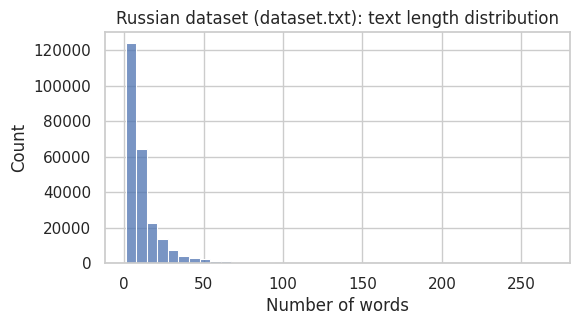


Label distribution:


,count
labels,
NORMAL,203685
INSULT,36826
THREAT,12027
OBSCENITY,4261


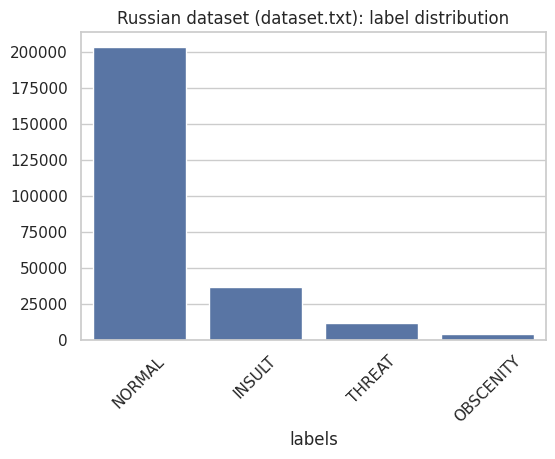


=== EDA: YouTube EN (raw) ===
Shape: (1000, 15)
Empty texts: 0
Average length (words): 33.78


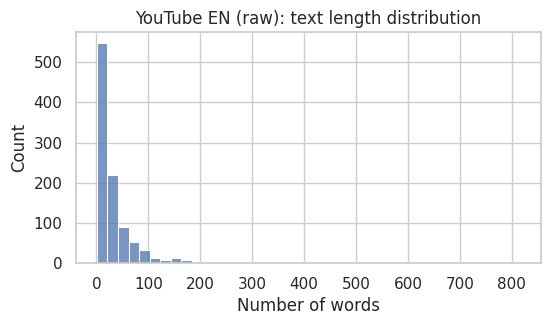


=== EDA: Toxic Comment EN (raw) ===
Shape: (159571, 7)
Empty texts: 0
Average length (words): 67.27


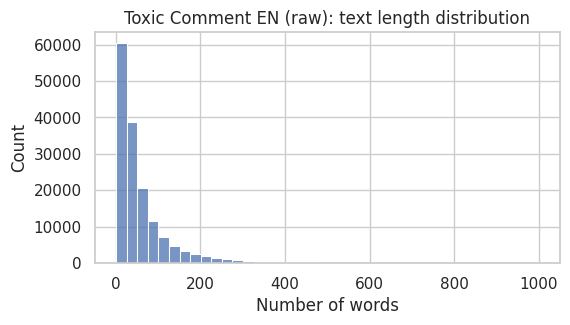

toxic      1111011000000000000000001101111100110010100000...
obscene    0010010000000000000000000101011100110010000000...
insult     0010011000000000000000000101010100110010000000...
threat     0000000000000000000000000000010000000000000000...
dtype: object


In [13]:
run_text_eda(
    df=df_rus,
    text_col="text",
    label_col="labels",
    title="Russian dataset (dataset.txt)"
)

run_text_eda(
    df=df_yt_raw,
    text_col="Text",
    title="YouTube EN (raw)"
)
bool_cols = [c for c in df_yt_raw.columns if c.startswith("Is")]
df_yt_raw[bool_cols].sum().sort_values(ascending=False)

run_text_eda(
    df=df_toxic_raw,
    text_col="comment_text",
    title="Toxic Comment EN (raw)"
)
label_cols = ["toxic","obscene","insult","threat"]
print(df_toxic_raw[label_cols].sum())

The EDA analysis shows a strong imbalance in the label distribution of the source dataset. This justifies the use of additional datasets. If those datasets are still not enough, we will use oversampling and downsampling.

To help the models handle insults and subtext more correctly, we will also add a Russian swear-word dictionary.


**Load the swear-word dictionary**


In [14]:
print("\nLoading the swear-word dictionary...")

SWEAR_CACHE = "swear_words_clean.pkl"

swear_df = pd.DataFrame(columns=["text_clean", "labels", "source"])

try:
    # Dataset loading
    ds = load_dataset("ilyaxin/Russian-Swear-Words", split="train")

    print("Dataset size:", len(ds))

    # Inspect the first 5 rows
    first_five = ds.select(range(5))
    for item in first_five:
        print(item)
except Exception as e:
    print("Dictionary loading error:", e)


Loading the swear-word dictionary...


README.md:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

russian-swears.json:   0%|          | 0.00/260k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/403 [00:00<?, ? examples/s]

Dataset size: 403
{'word': 'блядь ', 'definition': 'Публичная женщина, проститутка; вообще распутная женщина. Обман, mendacium, — Блядь бо есть то и лжа.... Вздор, пустяки, deliramentum, nugae: Cмех то и блядь!, Их же (язычников) — бляди мне вся жертвы!, Кощюнные бляди, Притча то суть и блядь — Козм. пресв. о ерес. Да не почитають первосписаных блядии и кощюнь но истинное да почитають о Хѣ (Христе) Гѣ (Господе) нашем. Муч. Кир. Ул.. Обманщик, fallax: Молъвящим же людем на Иоанна и глющим (глаголющим?) йако блядь есть. Прох. Жит. Iо. Богосл. XLII.. Безумный, insanus: Умри, блядь, умри!. Прелюбодейка, meretrix: Аще кто зовётъ чюжую жену блядью..., Церк. Уст. Яросл. Любодейка Во множ.числе, — бляди, блядей; в старинном языке — злохуление, поносительныя речи Ложь, обман В нынешнем языке: непотребная женщина, блудница Болтун, пустомеля Пустая болтовня, неразумно мовленне Заблуждение, ересь, — blud Распутство, разврат Распутная женщина Ложь, обман Ересь, лжеучение Лжец, обманщик Распутная же

The dataset structure is simple. We only need the `word` column. All swear words will be labeled as INSULT and added to the final dataset later. First, we clean it and bring it to the common dataset structure.


In [15]:
# Take only the word column (without definition)
# directly into pandas (save memory)
words = pd.Series(ds["word"], dtype="string")

# Cleaning
words = (
    words
    .dropna()
    .str.strip()
    .str.lower()
    .map(demask_text)
    .map(clean_minimal)
)

# remove empty values and duplicates
words = words[words.str.len() > 0].drop_duplicates().reset_index(drop=True)

print("Unique tokens:", len(words))

# DataFrame creation

swear_df = pd.DataFrame({
    "text_clean": words.values,
    "labels": [["INSULT"]] * len(words),
    "source": "swear_dict"
})

# Saving
joblib.dump(swear_df, SWEAR_CACHE)
print("Saved:", SWEAR_CACHE)

print("Shape:", swear_df.shape)

# Clean memory
del words, ds
gc.collect()

Unique tokens: 398
Saved: swear_words_clean.pkl
Shape: (398, 3)


3601

In [16]:
# Inspect the result
swear_df.head(5)

,text_clean,labels,source
0,блядь,[INSULT],swear_dict
1,ебать,[INSULT],swear_dict
2,хуй,[INSULT],swear_dict
3,беспиздая,[INSULT],swear_dict
4,бля,[INSULT],swear_dict


# Preliminary processing of English datasets

Before translating the datasets, they need to be processed.

This block normalizes the English-language datasets: it converts binary labels to Boolean type, adaptively finds text fields, and restores masked toxicity. This is critical for correct translation and training; otherwise, the model loses a significant part of the toxic signal.


**Processing reihanenamdari/youtube-toxicity-data**


In [17]:
if not df_yt_raw.empty:
    bool_cols = [
        "IsToxic","IsAbusive","IsThreat","IsProvocative","IsObscene",
        "IsHatespeech","IsRacist","IsNationalist","IsSexist",
        "IsHomophobic","IsReligiousHate","IsRadicalism"
    ]

    # Type normalization:
    # True - "True"
    # False - "False"
    # NaN - "nan"
    for c in bool_cols:
        if c in df_yt_raw.columns:
            df_yt_raw[c] = (
                df_yt_raw[c]
                .astype(str)
                .str.upper()
                .astype(str).str.lower().map({
                    "true": True,
                    "false": False,
                    "1": True,
                    "0": False
                })
                .fillna(False)
            )
        else:
            df_yt_raw[c] = False

    # Normalize the column name so the rest of the pipeline can use one name.
    if "Text" not in df_yt_raw.columns:
        cand = [c for c in df_yt_raw.columns if "text" in c.lower()]
        if cand:
            df_yt_raw.rename(columns={cand[0]: "Text"}, inplace=True)

    # Text cleaning and demasking
    df_yt_raw["Text"] = (
        df_yt_raw["Text"]
        .astype(str)
        .apply(demask_text)
    )

**Processing jahangirhussen/toxic-comment**


In [18]:
if not df_toxic_raw.empty:
    # Remove the irrelevant class
    if "identity_hate" in df_toxic_raw.columns:
        df_toxic_raw = df_toxic_raw.drop(columns=["identity_hate"])
    # Normalize the text-column name to avoid conflicts
    if "comment_text" not in df_toxic_raw.columns:
        cands = [c for c in df_toxic_raw.columns if "comment" in c.lower()]
        if cands:
            df_toxic_raw.rename(columns={cands[0]:"comment_text"}, inplace=True)

    # Text cleaning and demasking
    df_toxic_raw['comment_text'] = df_toxic_raw['comment_text'].astype(str)
    df_toxic_raw['comment_text'] = df_toxic_raw['comment_text'].apply(demask_text)

**Filter English-language datasets before translation**

Translating millions of “ordinary” comments is pointless and harmful. This code filters the English-language datasets before translation, keeping only toxic and potentially toxic comments.
This allows us to speed up translation significantly, reduce GPU/VRAM usage, avoid polluting the dataset with irrelevant NORMAL phrases, and thereby improve model training quality.


In [19]:
print("\nFiltering English-language datasets before translation...")

# reihanenamdari/youtube-toxicity-data
df_yt_filtered = pd.DataFrame()
if not df_yt_raw.empty:
    # Define useful rows; ignore IsNormal for balance.
    # If at least one value is True, the row is useful
    def yt_useful_row(r):
        return (r.get("IsThreat",False)==True) or (r.get("IsObscene",False)==True) or any(r.get(c,False)==True for c in ["IsToxic","IsRacist","IsNationalist","IsHomophobic","IsReligiousHate"])
    # Filtering. Keep only True rows.
    df_yt_filtered = df_yt_raw[df_yt_raw.apply(yt_useful_row, axis=1)].reset_index(drop=True)
    print("YT useful rows:", len(df_yt_filtered))

# jahangirhussen/toxic-comment
df_toxic_filtered = pd.DataFrame()
if not df_toxic_raw.empty:
    def toxic_useful_row(r):
        for fld in ["toxic","obscene","insult","threat","severe_toxic","identity_hate"]:
            if fld in r.index and str(r[fld]).strip() in ["1","True","TRUE","true"]:
                return True
        return False
    df_toxic_filtered = df_toxic_raw[df_toxic_raw.apply(toxic_useful_row, axis=1)].reset_index(drop=True)
    print("toxic useful rows:", len(df_toxic_filtered))


Filtering English-language datasets before translation...
YT useful rows: 462
toxic useful rows: 16171


# 4. Translation block


**Translation of filtered English-language datasets**

Parquet is used for the cache. It is compact, fast, and preserves data types.


In [20]:
print("\nTranslating filtered English-language datasets. If caches exist, load them to save time.")

# reihanenamdari/youtube-toxicity-data

if not df_yt_filtered.empty:

    # Check the prepared dataset cache
    if os.path.exists(YT_TRANSL_CACHE):
        df_yt_trans = pd.read_parquet(YT_TRANSL_CACHE)

        # Protection against old caches
        if "text_clean" not in df_yt_trans.columns:
            df_yt_trans["text_clean"] = (
                df_yt_trans
                .get("text_ru", df_yt_trans.get("Text", ""))
                .astype(str)
                .apply(clean_minimal)
            )

    else:
        # Text preparation
        texts = (
            df_yt_filtered["Text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        # Translation (fp16 + NLLB inside translate_texts_safe)
        translated = translate_texts_safe(
            texts,
            batch_size=64,                     # safer for fp16
            max_length=TRANSLATION_MAX_TOKENS,
            n_workers=2,
            cache_file=TRANSLATION_CACHE       # GLOBAL cache
        )

        # Dataset assembly
        df_yt_trans = df_yt_filtered.copy().reset_index(drop=True)
        df_yt_trans["text_ru"] = translated
        df_yt_trans["text_clean"] = (
            df_yt_trans["text_ru"]
            .astype(str)
            .apply(clean_minimal)
        )

        # Save the prepared dataset
        df_yt_trans.to_parquet(YT_TRANSL_CACHE, index=False)
        print("YT translation saved to cache ->", YT_TRANSL_CACHE)

else:
    df_yt_trans = pd.DataFrame()


# jahangirhussen/toxic-comment

if not df_toxic_filtered.empty:

    # Check the prepared dataset cache
    if os.path.exists(TOXIC_TRANSL_CACHE):
        df_toxic_trans = pd.read_parquet(TOXIC_TRANSL_CACHE)

        if "text_clean" not in df_toxic_trans.columns:
            df_toxic_trans["text_clean"] = (
                df_toxic_trans
                .get("text_ru", df_toxic_trans.get("comment_text", ""))
                .astype(str)
                .apply(clean_minimal)
            )

    else:
        # Text preparation
        texts = (
            df_toxic_filtered["comment_text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        # Translation
        translated = translate_texts_safe(
            texts,
            batch_size=64,
            max_length=TRANSLATION_MAX_TOKENS,
            n_workers=2,
            cache_file=TRANSLATION_CACHE       # GLOBAL cache
        )

        # Dataset assembly
        df_toxic_trans = df_toxic_filtered.copy().reset_index(drop=True)
        df_toxic_trans["text_ru"] = translated
        df_toxic_trans["text_clean"] = (
            df_toxic_trans["text_ru"]
            .astype(str)
            .apply(clean_minimal)
        )

        # Saving
        df_toxic_trans.to_parquet(TOXIC_TRANSL_CACHE, index=False)
        print("toxic translation saved to cache ->", TOXIC_TRANSL_CACHE)

else:
    df_toxic_trans = pd.DataFrame()


Translating filtered English-language datasets. If caches exist, load them to save time.


**Check the result**


In [21]:
translated_yt = pd.read_parquet("yt_translated_ru.parquet")
translated_toxic = pd.read_parquet("toxic_translated_ru.parquet")
translated_cache = pd.read_parquet("translation_cache.parquet")

print("\nYOUTUBE")
translated_yt.head(5)


YOUTUBE


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,text_ru,text_clean
0,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,"Правоохранительные органы не обучены стрелять,...","правоохранительные органы не обучены стрелять,..."
1,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,"Не считаете ли вы, что плакаты ""черные жизни и...","не считаете ли вы, что плакаты ""черные жизни и..."
2,Ugg9a6FtoXdxmXgCoAEC,04kJtp6pVXI,here people his facebook is https://ww.faceboo...,True,False,False,False,False,True,False,False,False,False,True,False,Вот люди его фейсбук https://www.facebook.com/...,вот люди его фейсбук у него есть связи с игил ...
3,Ugga9KzkNDGvlXgCoAEC,04kJtp6pVXI,"Check out this you tube post. ""Black man goes ...",True,False,False,False,False,True,True,False,False,False,False,False,"""Чёрный человек выступает против бунтовщиков Ф...","""чёрный человек выступает против бунтовщиков ф..."
4,UggBlIXoph7p-3gCoAEC,04kJtp6pVXI,I would LOVE to see this pussy go to Staten Is...,True,True,False,False,True,True,True,False,False,False,False,False,"Я бы очень хотел, чтобы эта кукла пошла на Ста...","я бы очень хотел, чтобы эта кукла пошла на ста..."


In [22]:
print("\nTOXIC")
translated_toxic.head(5)


TOXIC


,comment_text,toxic,severe_toxic,obscene,threat,insult,text_ru,text_clean
0,!\n\nI won't stop! LOCK IT UP AHOLE,1,0,0,0,0,Я не останавливаюсь!,я не останавливаюсь!
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,"Он сейчас в твоих костях, в твоей голове, прес...","он сейчас в твоих костях, в твоей голове, прес..."
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,"Нигга, ты не хочешь, чтобы люди узнали правду ...","нигга, ты не хочешь, чтобы люди узнали правду ..."
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,Почему никто меня не запрещает?,почему никто меня не запрещает?
4,!\nWant to explain to me why you can revert yo...,1,0,1,0,1,"Хочешь объяснить мне, почему ты можешь перевер...","хочешь объяснить мне, почему ты можешь перевер..."


In [23]:
print("\nCACHE")
translated_cache.head(5)


CACHE


,original,translated
0,Law enforcement is not trained to shoot to app...,"Правоохранительные органы не обучены стрелять,..."
1,\nDont you reckon them 'black lives matter' ba...,"Не считаете ли вы, что плакаты ""черные жизни и..."
2,here people his facebook is https://ww.faceboo...,Вот люди его фейсбук https://www.facebook.com/...
3,"Check out this you tube post. ""Black man goes ...","""Чёрный человек выступает против бунтовщиков Ф..."
4,I would LOVE to see this pussy go to Staten Is...,"Я бы очень хотел, чтобы эта кукла пошла на Ста..."


**Create labels for translated data**

This is the key block where “raw translations” are converted into training examples for multi-label classification.

We bring heterogeneous datasets to a unified multi-label system, discard rows without relevant classes, and explicitly preserve the data source. This makes it possible to merge corpora correctly and control each source’s contribution to training.

Map the English-language dataset labels as follows:

**1. reihanenamdari/youtube-toxicity-data**

IsNormal — ignored (NORMAL strongly dominates)

IsThreat — THREAT

IsObscene — OBSCENITY

Other labels:
IsToxic IsAbusive IsProvocative IsHatespeech IsRacist
IsNationalist IsSexist IsHomophobic IsReligiousHate — INSULT

This is verbal aggression, not profanity and not a direct threat,
so semantically it is closer to INSULT.

**2. jahangirhussen/toxic-comment**

threat — THREAT

obscene — OBSCENITY

Other labels:
toxic, insult, severe_toxic, identity_hate — INSULT


In [24]:
# reihanenamdari/youtube-toxicity-data
# Pipeline protection. If the dataset was not loaded or was filtered to 0 rows, the code will not crash
if not df_yt_trans.empty:
    print("df_yt_trans size:", len(df_yt_trans))
    # Remap labels to our label set.
    df_yt_trans['labels'] = df_yt_trans.apply(yt_labels, axis=1)
    # Drop empty labels if any passed filtering or lost the flag during cleaning
    df_yt_used = df_yt_trans[df_yt_trans['labels'].map(lambda L: len(L)>0)].copy()
    # Mark the data source
    df_yt_used['source'] = 'youtube_en_translated'
else:
    df_yt_used = pd.DataFrame()

# jahangirhussen/toxic-comment
if not df_toxic_trans.empty:
    df_toxic_trans['labels'] = df_toxic_trans.apply(toxic_labels, axis=1)
    df_toxic_used = df_toxic_trans[df_toxic_trans['labels'].map(lambda L: len(L)>0)].copy()
    df_toxic_used['source'] = 'toxic_en_translated'
else:
    df_toxic_used = pd.DataFrame()

df_yt_trans size: 462


In [25]:
df_yt_used.head(5)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,text_ru,text_clean,labels,source
0,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,"Правоохранительные органы не обучены стрелять,...","правоохранительные органы не обучены стрелять,...",[INSULT],youtube_en_translated
1,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,"Не считаете ли вы, что плакаты ""черные жизни и...","не считаете ли вы, что плакаты ""черные жизни и...","[OBSCENITY, INSULT]",youtube_en_translated
2,Ugg9a6FtoXdxmXgCoAEC,04kJtp6pVXI,here people his facebook is https://ww.faceboo...,True,False,False,False,False,True,False,False,False,False,True,False,Вот люди его фейсбук https://www.facebook.com/...,вот люди его фейсбук у него есть связи с игил ...,[INSULT],youtube_en_translated
3,Ugga9KzkNDGvlXgCoAEC,04kJtp6pVXI,"Check out this you tube post. ""Black man goes ...",True,False,False,False,False,True,True,False,False,False,False,False,"""Чёрный человек выступает против бунтовщиков Ф...","""чёрный человек выступает против бунтовщиков ф...",[INSULT],youtube_en_translated
4,UggBlIXoph7p-3gCoAEC,04kJtp6pVXI,I would LOVE to see this pussy go to Staten Is...,True,True,False,False,True,True,True,False,False,False,False,False,"Я бы очень хотел, чтобы эта кукла пошла на Ста...","я бы очень хотел, чтобы эта кукла пошла на ста...","[OBSCENITY, INSULT]",youtube_en_translated


In [26]:
df_toxic_used.head(5)

,comment_text,toxic,severe_toxic,obscene,threat,insult,text_ru,text_clean,labels,source
0,!\n\nI won't stop! LOCK IT UP AHOLE,1,0,0,0,0,Я не останавливаюсь!,я не останавливаюсь!,[INSULT],toxic_en_translated
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,"Он сейчас в твоих костях, в твоей голове, прес...","он сейчас в твоих костях, в твоей голове, прес...",[INSULT],toxic_en_translated
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,"Нигга, ты не хочешь, чтобы люди узнали правду ...","нигга, ты не хочешь, чтобы люди узнали правду ...","[INSULT, OBSCENITY]",toxic_en_translated
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,Почему никто меня не запрещает?,почему никто меня не запрещает?,[INSULT],toxic_en_translated
4,!\nWant to explain to me why you can revert yo...,1,0,1,0,1,"Хочешь объяснить мне, почему ты можешь перевер...","хочешь объяснить мне, почему ты можешь перевер...","[INSULT, OBSCENITY]",toxic_en_translated


**Merging all sources**

This is the key stage of assembling the final dataset. Here we carefully merge all data sources into one corpus, bring the format to a single standard, and add service features for analysis and balancing.


In [27]:
# Create the list of frames
frames = [df_rus[['text_clean','labels','source']].copy()]

# Conditionally add translated data
if not df_yt_used.empty:
    frames.append(df_yt_used[['text_clean','labels','source']])
if not df_toxic_used.empty:
    frames.append(df_toxic_used[['text_clean','labels','source']])
# Add synthetic data (swear words)
if not swear_df.empty:
    frames.append(swear_df[['text_clean','labels','source']])

# Merge all sources and shuffle the data
df_full = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
# Normalize label format
df_full['labels'] = df_full['labels'].apply(lambda L: list(L) if isinstance(L,(list,tuple)) else [L])
# Number of labels
df_full['label_count'] = df_full['labels'].apply(len)
# Text length (in words)
df_full['word_count'] = df_full['text_clean'].apply(lambda s: len(str(s).split()))
print('Rows after merging:', len(df_full))

Rows after merging: 265321


In [28]:
df_full.tail(15)

,text_clean,labels,source,label_count,word_count
265306,"иди, трахнись, пока она не упадет.","[INSULT, OBSCENITY]",toxic_en_translated,2,6
265307,зачем трусы то снял?)),[NORMAL],ru_original,1,4
265308,пипец игруха виснет. можно литряк заглотить по...,[NORMAL],ru_original,1,11
265309,убился мультом (sr),[NORMAL],ru_original,1,3
265310,"что, вроде норм",[NORMAL],ru_original,1,3
265311,какой хороший друг - всегда при тебе...,[NORMAL],ru_original,1,7
265312,обожаю его просто супер!,[NORMAL],ru_original,1,4
265313,люди не проходите мимо не буте жестоки🌹,[NORMAL],ru_original,1,7
265314,сбербанк онлайн чек по операции онлайн сбербан...,[NORMAL],ru_original,1,58
265315,"войска китая,войска нато уже в хабаровске.",[NORMAL],ru_original,1,6


# 5. Final preprocessing before training

Here we run an extended EDA analysis of the final data, balance it through oversampling and trimming, and visualize the results for clarity.


**EDA before balancing**



EDA before balancing:

=== EDA: Final dataset (before balancing) ===
Shape: (265321, 5)
Empty texts: 3
Average length (words): 13.16


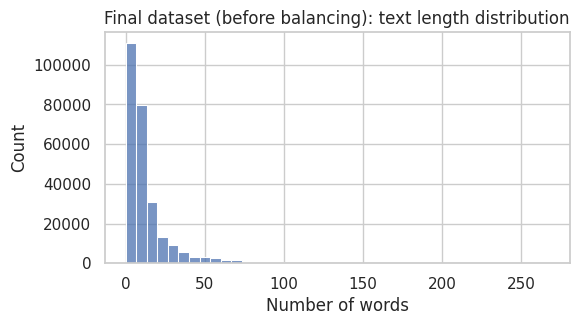


Label distribution:


,count
labels,
NORMAL,203685
INSULT,53513
OBSCENITY,12810
THREAT,12526


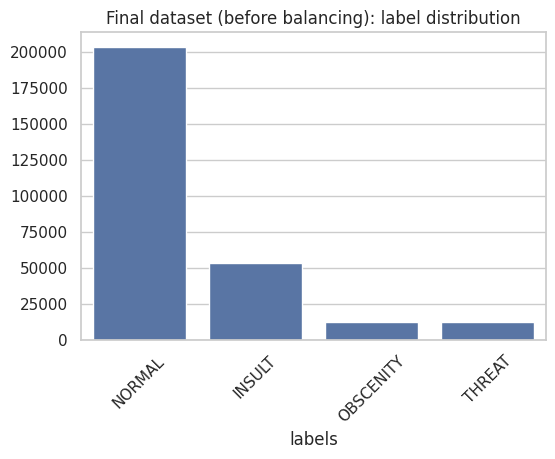

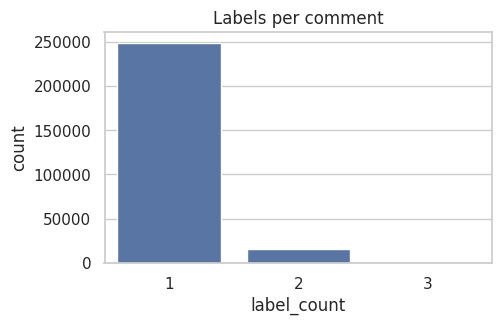

In [29]:
print('\nEDA before balancing:')

run_text_eda(
    df=df_full,
    text_col="text_clean",
    label_col="labels",
    title="Final dataset (before balancing)"
)

# Number of labels per comment
plt.figure(figsize=(5,3)); sns.countplot(x=df_full['label_count']); plt.title('Labels per comment'); plt.show()

During EDA, we analyzed the label distribution, text lengths, and the share of multi-label examples. This revealed a strong skew toward NORMAL, the presence of masked toxic vocabulary, and the rarity of the THREAT label. Based on these observations, we decided to reduce NORMAL examples and train separate binary classifiers with individual thresholds.


**Balancing**

This block implements a moderate data balancing strategy. We strengthen rare toxic classes through oversampling while limiting the dominant NORMAL class by first removing short irrelevant comments. This approach preserves a realistic data distribution, avoids overfitting, and provides stable training for all labels.


In [30]:
# The output always contains a DataFrame with columns:
#   - text_clean
#   - labels

COMBINED_CSV = "combined_dataset.csv"
COMBINED_PARQUET = "combined_dataset.parquet"

if os.path.exists(COMBINED_CSV):
    print(f"Dataset cache found: {COMBINED_CSV}")
    df = pd.read_csv(COMBINED_CSV)
    df["text_clean"] = df["text_clean"].astype(str)
    df["labels"] = df["labels"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    print("Dataset shape:", df.shape)
    display(df.sample(3, random_state=RANDOM_STATE))

else:
    print("COMBINED_CSV not found. Creating the dataset from scratch")

    print("\nApplying oversampling / downsampling...")

    # Basic checks

    required_cols = {"text_clean", "labels", "word_count"}
    missing = required_cols - set(df_full.columns)
    if missing:
        raise ValueError(f"df_full is missing required columns: {missing}")

    print("Initial dataset size:", df_full.shape)
    print("Label distribution before balancing:")
    print(df_full["labels"].explode().value_counts())

    # Split the dataset by type:

    # NORMAL only
    df_normals = df_full[df_full["labels"].apply(lambda L: L == ["NORMAL"])].copy()

    # INSULT only
    df_insult_only = df_full[df_full["labels"].apply(lambda L: L == ["INSULT"])].copy()

    # Multi-label rows with INSULT
    df_insult_multi = df_full[
        df_full["labels"].apply(lambda L: "INSULT" in L and L != ["INSULT"])
    ].copy()

    # All THREAT rows (including multi-label rows)
    df_threat = df_full[df_full["labels"].apply(lambda L: "THREAT" in L)].copy()

    # All OBSCENITY rows (including multi-label rows)
    df_obscene = df_full[df_full["labels"].apply(lambda L: "OBSCENITY" in L)].copy()

    print("\nSplit completed:")
    print(f"  NORMAL:        {len(df_normals)}")
    print(f"  INSULT only:   {len(df_insult_only)}")
    print(f"  INSULT multi:  {len(df_insult_multi)}")
    print(f"  THREAT:        {len(df_threat)}")
    print(f"  OBSCENITY:     {len(df_obscene)}")


    # Balancing

    # INSULT-only:
    if MULT_INSULT < 1.0:
        df_insult_only_bal = downsample_df(df_insult_only, MULT_INSULT)
    else:
        df_insult_only_bal = upsample_df(df_insult_only, MULT_INSULT)

    # THREAT
    if MULT_THREAT < 1.0:
        df_threat_up = downsample_df(df_threat, MULT_THREAT)
    else:
        df_threat_up = upsample_df(df_threat, MULT_THREAT)

    # OBSCENITY
    if MULT_OBSCENITY < 1.0:
        df_obscene_up = downsample_df(df_obscene, MULT_OBSCENITY)
    else:
        df_obscene_up = upsample_df(df_obscene, MULT_OBSCENITY)

    # NORMAL limitation

    # Remove too-short NORMAL comments
    df_normals = df_normals[df_normals["word_count"] >= 3].copy()

    # Upper cap so NORMAL does not dominate
    MAX_NORMALS = max(100_000, len(df_insult_only_bal))
    if len(df_normals) > MAX_NORMALS:
        df_normals = df_normals.sample(n=MAX_NORMALS, random_state=RANDOM_STATE)

    print("\nAfter limiting NORMAL:")
    print(f"  NORMAL: {len(df_normals)}")


    # Final assembly

    frames_bal = [
        df_normals,
        df_insult_only_bal,
        df_insult_multi,    # always keep multi-label rows
        df_threat_up,
        df_obscene_up
    ]

    df_balanced = (
        pd.concat(frames_bal, ignore_index=True)
          .sample(frac=1, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )

    print("\nFinal dataset size:", df_balanced.shape)
    print("Label distribution after balancing:")
    print(df_balanced["labels"].explode().value_counts())


    # CHECKS AND SERVICE FIELDS

    # Number of labels for one object
    df_balanced["label_count"] = df_balanced["labels"].apply(len)

    # Protection against empty texts
    df_balanced = df_balanced[
        df_balanced["text_clean"].notna() &
        (df_balanced["text_clean"].str.len() > 0)
    ].reset_index(drop=True)

    # EDA
    run_text_eda(
        df=df_balanced,
        text_col="text_clean",
        label_col="labels",
        title="Final dataset (after balancing)"
    )

    plt.figure(figsize=(5, 3))
    sns.countplot(x=df_balanced["label_count"])
    plt.title("Labels per comment")
    plt.show()


    # SAVING COMBINED_CSV
    # Keep ONLY text_clean and labels
    print("\nSaving the final dataset...")

    df_final = df_balanced[["text_clean", "labels"]].copy()

    df_final.to_csv(COMBINED_CSV, index=False)
    print(f"Final dataset saved: {COMBINED_CSV}")

    df_final.to_parquet(COMBINED_PARQUET, index=False)
    print(f"Final dataset also saved as parquet: {COMBINED_PARQUET}")

    # Load into df for the next steps
    df = df_final.copy()


# STRICT VALIDATION

required_cols = {"text_clean", "labels"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"combined_dataset is missing required columns: {missing}")

df["text_clean"] = df["text_clean"].astype(str)
df["labels"] = df["labels"].apply(lambda x: list(x) if isinstance(x, (list, tuple, set)) else x)

print("\nCombined dataset is ready to use")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
display(df.sample(5, random_state=RANDOM_STATE))

Dataset cache found: combined_dataset.csv
Dataset shape: (247305, 2)


,text_clean,labels
138131,хорошо это вода,[NORMAL]
211071,"к сожалению, у меня нет лекарства от глупости....",[INSULT]
142361,shutup [[who u think u is you gay nobody that'...,"[INSULT, OBSCENITY]"



Combined dataset is ready to use
Rows: 247305
Columns: ['text_clean', 'labels']


,text_clean,labels
138131,хорошо это вода,[NORMAL]
211071,"к сожалению, у меня нет лекарства от глупости....",[INSULT]
142361,shutup [[who u think u is you gay nobody that'...,"[INSULT, OBSCENITY]"
86573,этих тварей нужно стрелять.,"[INSULT, THREAT]"
140846,полно хватало наглых и прохиндеев.,[NORMAL]


# **Final dataset conclusions:**

**Dataset size:** 247,305 comments

**Empty texts:** 0

**Average comment length:** 14.83 words. Most comments are under 20 words. Long texts are rare. The distribution has a long tail, which is typical for real comments.

**This means the data has been successfully cleaned and empty rows have been removed.**

The classes are now much more balanced than in the original data. The gap between classes has been reduced, and rare classes have been increased through dataset merging and upsampling. THREAT has increased substantially in particular, and OBSCENITY has also been strengthened.
NORMAL has been limited to 100,000 comments to avoid model bias (toxic comments often received the NORMAL label or the multi-label combination INSULT+NORMAL).

Most comments have one label. There are quite a few double-label examples, while triple-label examples are rare. This is normal for multi-label toxicity detection. **Therefore, we have enough data for the models to learn label combinations.**


# 6. Model training


**Preparing X/Y and splits**

This block converts labels into a machine-learnable format. We prepare input features (X) and target variables (Y). Then we correctly split the data into Train / Validation / Test.

This approach preserves the balance and complexity of examples during splitting.

In other words, this code prepares the data for correct training and fair model evaluation.


Input: a DataFrame with the columns `text_clean` of type `str` and `labels` of type `list[str]`.

Output: `X_train`, `X_val`, `X_test` of type `list[str]` (or `np.ndarray` with `dtype=object`), and `y_train`, `y_val`, `y_test` of type `np.ndarray` (`int8` / `uint8`).

We will save `mlb` to cache.


**MultiLabelBinarizer**


In [31]:
MLB_PATH = "mlb.pkl"

print("\nMultiLabelBinarizer")

labels_list = df["labels"].tolist()   # list[list[str]]

if os.path.exists(MLB_PATH):
    print("mlb loaded from cache")
    mlb = joblib.load(MLB_PATH)
    Y = mlb.transform(labels_list)
else:
    print("Training mlb...")
    mlb = MultiLabelBinarizer()
    Y = mlb.fit_transform(labels_list)
    joblib.dump(mlb, MLB_PATH)
    print(f"mlb saved: {MLB_PATH}")

Y = Y.astype(np.uint8)   # save memory

labels = list(mlb.classes_)
print("Classes:", labels)
print("Y shape:", Y.shape, "dtype:", Y.dtype)


MultiLabelBinarizer
mlb loaded from cache
Classes: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']
Y shape: (247305, 4) dtype: uint8


**Create X as a Python list, without pandas**


In [32]:
print("\nCreating X")

X = df["text_clean"].astype(str).tolist()
print(f"X size: {len(X)}")


Creating X
X size: 247305


**Feature for stratification**


In [33]:
print("\nPreparing stratification")

# Number of active labels per object
label_count = np.array([len(x) for x in labels_list], dtype=np.int16)

unique, counts = np.unique(label_count, return_counts=True)
print("label_count distribution:")
for u, c in zip(unique, counts):
    print(f"  {u:2d} = {c}")


Preparing stratification
label_count distribution:
   1 = 141173
   2 = 100841
   3 = 5291


Now we need to split the data into Train/Validation/Test.

**Train** is used to train the model.

**Validation** is needed for model tuning. It is used for hyperparameter selection, best-model selection, threshold tuning, and ensemble selection. Therefore, it is logical to cut it out of Train.

**Test** is used to evaluate the trained model.

First, we perform a Train/Test split to immediately separate Test. After that, we separate Validation from the remaining Train subset. This approach prevents information leakage and also makes it easier to change the Validation size and use Cross-Validation. This is a practical standard in ML.

It would not be wrong to perform a Train/Validation/Test split immediately, but this project has a complex pipeline where control over Validation is especially important. The approximate scheme is as follows:


In [34]:
#FULL DATA
#   │
#   ├── Train (80%)
#   │      │
#   │      ├── Train_inner
#   │      └── Validation
#   │             │
#   │             ├── model selection
#   │             ├── ensemble selection
#   │             └── threshold tuning
#   │
#   └── Test (20%)
#          │
#          └── final check

**Train / Test split**


In [35]:
print("\nTrain / Test split")

(
    X_train_full,
    X_test,
    y_train_full,
    y_test,
    lc_train_full,
    lc_test,
) = train_test_split(
    X,
    Y,
    label_count,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=label_count
)

print(f"Train_full: {len(X_train_full)}")
print(f"Test      : {len(X_test)}")


Train / Test split
Train_full: 197844
Test      : 49461


**Train / Validation split**


In [36]:
print("\nTrain / Validation split")

train_label_counts = y_train_full.sum(axis=1).astype(np.int16)

(
    X_train,
    X_val,
    y_train,
    y_val,
) = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=train_label_counts
)

print(f"Train: {len(X_train)}")
print(f"Val  : {len(X_val)}")
print(f"Test : {len(X_test)}")


Train / Validation split
Train: 168167
Val  : 29677
Test : 49461


**Balance check + fixing random generators**

If we want to run the code using cached data, we must fix the random number generators. Otherwise, repeated execution will produce completely different results. For example, after training a model to 98% accuracy, a repeated run may cause metrics to drop by at least a third.


In [37]:
print("\nLabel balance check by split:")

def print_label_stats(name, Y_split):
    counts = Y_split.sum(axis=0)
    print(f"\n{name}:")
    for lab, cnt in zip(labels, counts):
        print(f"  {lab:12s}: {int(cnt)}")

print_label_stats("TRAIN", y_train)
print_label_stats("VAL",   y_val)
print_label_stats("TEST",  y_test)

print("\nFixing RANDOM_STATE")

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

print("RANDOM_STATE fixed")


Label balance check by split:

TRAIN:
  INSULT      : 74145
  NORMAL      : 67987
  OBSCENITY   : 60751
  THREAT      : 41052

VAL:
  INSULT      : 13071
  NORMAL      : 12028
  OBSCENITY   : 10759
  THREAT      : 7190

TEST:
  INSULT      : 21828
  NORMAL      : 19985
  OBSCENITY   : 17794
  THREAT      : 12138

Fixing RANDOM_STATE
RANDOM_STATE fixed


**Memory cleanup and final check**


In [38]:
# Memory cleanup

print("\n Freeing RAM")

del df
del labels_list
del label_count
del lc_train_full, lc_test
del X_train_full, y_train_full
gc.collect()

# Final check

print("\nFinal size check:")

print("X_train:", len(X_train))
print("X_val  :", len(X_val))
print("X_test :", len(X_test))

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

assert len(X_train) == y_train.shape[0]
assert len(X_val)   == y_val.shape[0]
assert len(X_test)  == y_test.shape[0]


 Freeing RAM

Final size check:
X_train: 168167
X_val  : 29677
X_test : 49461
y_train: (168167, 4)
y_val  : (29677, 4)
y_test : (49461, 4)


Now the entire pipeline works without pandas. X has type `list[str]`, and Y is a NumPy `uint8` array. This reduces RAM usage without loss of quality.


**TF-IDF (word+char) and SVD**

This is the central part of the entire feature pipeline. It converts text into numeric features and captures semantics, morphology, and masked profanity. It prepares two representations:

***1. Sparse (TF-IDF)*** — for tree-based models and boosting.

***TF-IDF (Term Frequency-Inverse Document Frequency)*** is a statistical method for estimating the importance of a word in a document relative to a collection of documents. It shows how unique and meaningful a word is for a specific text. It is calculated as the product of Term Frequency (TF), which reflects the number of occurrences of a word in a document, and Inverse Document Frequency (IDF), which reduces the weight of frequently used words (prepositions, conjunctions), making them less significant.

***2. Dense (SVD)*** — for linear and neural-network models.

***Singular Value Decomposition (SVD)*** is a decomposition of a real-valued matrix into a canonical form. SVD is a convenient method when working with matrices. It shows the geometric structure of the matrix and makes the available data easier to represent visually.

**Why SVD is needed**

TF-IDF is sparse and poorly suited for SVM, MLP, and logistic models. SVD compresses the space, preserves meaning, and makes features dense. This is Latent Semantic Analysis (LSA). Each model works in its optimal feature space.

This solution is robust to masking, memory-efficient, scalable, provides high recall, and is compatible with caching.


**TF-IDF OBJECTS**


In [39]:
print("\nTF-IDF objects")

if TFIDF_WORD_PATH.exists() and TFIDF_CHAR_PATH.exists():
    print("TF-IDF loaded from cache")
    word_tfidf = joblib.load(TFIDF_WORD_PATH)
    char_tfidf = joblib.load(TFIDF_CHAR_PATH)
else:
    print("Training TF-IDF...")
    word_tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        analyzer="word",
        dtype=np.float32
    )

    char_tfidf = TfidfVectorizer(
        max_features=CHAR_TFIDF_MAX,
        ngram_range=(3, 5),
        analyzer="char_wb",
        sublinear_tf=True,
        dtype=np.float32
    )

    t0 = time.time()
    word_tfidf.fit(X_train)
    char_tfidf.fit(X_train)
    print("TF-IDF fit time:", round(time.time() - t0, 2), "sec")

    joblib.dump(word_tfidf, TFIDF_WORD_PATH)
    joblib.dump(char_tfidf, TFIDF_CHAR_PATH)
    print("TF-IDF saved")


TF-IDF objects
TF-IDF loaded from cache


**TF-IDF MATRICES**


In [40]:
print("\nTF-IDF matrices")

if X_TRAIN_TFIDF_PATH.exists():
    print("Sparse TF-IDF loaded")
    X_train_tfidf = sp.load_npz(X_TRAIN_TFIDF_PATH)
    X_val_tfidf   = sp.load_npz(X_VAL_TFIDF_PATH)
    X_test_tfidf  = sp.load_npz(X_TEST_TFIDF_PATH)
else:
    print("Building sparse TF-IDF...")

    X_train_tfidf = sp.hstack([
        word_tfidf.transform(X_train),
        char_tfidf.transform(X_train)
    ], format="csr")

    X_val_tfidf = sp.hstack([
        word_tfidf.transform(X_val),
        char_tfidf.transform(X_val)
    ], format="csr")

    X_test_tfidf = sp.hstack([
        word_tfidf.transform(X_test),
        char_tfidf.transform(X_test)
    ], format="csr")

    sp.save_npz(X_TRAIN_TFIDF_PATH, X_train_tfidf)
    sp.save_npz(X_VAL_TFIDF_PATH,   X_val_tfidf)
    sp.save_npz(X_TEST_TFIDF_PATH,  X_test_tfidf)

    print("Sparse TF-IDF saved")


TF-IDF matrices
Sparse TF-IDF loaded


**SVD OBJECT + MATRICES**


In [41]:
print("\nSVD object + matrices")

if SVD_PATH.exists():
    print("SVD loaded from cache")
    svd = joblib.load(SVD_PATH)
else:
    print("Training SVD...")
    svd = TruncatedSVD(
        n_components=SVD_COMPONENTS,
        random_state=RANDOM_STATE
    )
    t0 = time.time()
    svd.fit(X_train_tfidf)
    print("SVD fit time:", round(time.time() - t0, 2), "sec")

    joblib.dump(svd, SVD_PATH)
    print("SVD saved")

# Convert SVD to sparse format and save it to cache. If the file exists, load it.
X_train_svd = svd_transform_and_cache(X_train_tfidf, X_TRAIN_SVD_PATH, "train")
X_val_svd   = svd_transform_and_cache(X_val_tfidf,   X_VAL_SVD_PATH,   "val")
X_test_svd  = svd_transform_and_cache(X_test_tfidf,  X_TEST_SVD_PATH,  "test")


SVD object + matrices
SVD loaded from cache
train SVD loaded
val SVD loaded
test SVD loaded


**META FEATURES**


In [42]:
print("\nMETA features")

# Convert to sparse format and save it to cache. If the file exists, load it.
meta_train = meta_to_sparse(X_train, META_TRAIN_PATH, "train")
meta_val   = meta_to_sparse(X_val,   META_VAL_PATH,   "val")
meta_test  = meta_to_sparse(X_test,  META_TEST_PATH,  "test")


META features
META train loaded
META val loaded
META test loaded


**Final matrices for models**


In [43]:
print("\nFinal matrices for models")

# For XGB and LGB: pure sparse TF-IDF
X_train_tfidf_lgb = X_train_tfidf
X_val_tfidf_lgb   = X_val_tfidf
X_test_tfidf_lgb  = X_test_tfidf

X_train_tfidf_xgb = X_train_tfidf
X_val_tfidf_xgb   = X_val_tfidf
X_test_tfidf_xgb  = X_test_tfidf

# For SVC: SVD only
X_train_svd_svc = X_train_svd
X_val_svd_svc   = X_val_svd
X_test_svd_svc  = X_test_svd

# For MLP: use SVD + META
X_train_mlp = build_mlp_matrix(X_train_svd, meta_train, X_TRAIN_MLP_PATH, "train")
X_val_mlp   = build_mlp_matrix(X_val_svd,   meta_val,   X_VAL_MLP_PATH,   "val")
X_test_mlp  = build_mlp_matrix(X_test_svd,  meta_test,  X_TEST_MLP_PATH,  "test")


Final matrices for models
MLP matrix train loaded
MLP matrix val loaded
MLP matrix test loaded


**Consistency check and memory cleanup**

Only sparse matrices remain in RAM. There is no DataFrame and no dense matrix. We try to avoid memory leaks as much as possible.


In [44]:
print("\n Consistency check and memory cleanup")

assert X_train_tfidf.shape[0] == y_train.shape[0]
assert X_val_tfidf.shape[0]   == y_val.shape[0]
assert X_test_tfidf.shape[0]  == y_test.shape[0]

assert X_train_svd_svc.shape[0] == y_train.shape[0]
assert X_train_mlp.shape[0]     == y_train.shape[0]

print("Deleting intermediate objects")

del meta_train, meta_val, meta_test
gc.collect()


 Consistency check and memory cleanup
Deleting intermediate objects


209

**Training models label by label**

We try four methods and choose the best one by validation F1.

Methods: LightGBM, XGBoost, LinearSVC (on SVD), MLP (on SVD).

The entire process is implemented in a loop. If a model has already been trained, we load it; otherwise, we start training and save the model to cache. For each label, we choose the two best models and test an ensemble of them. Ensembles often produce lower F1 than a solo model, but in real usage models trained with different methods can compensate for each other’s weaknesses and perform better than the metrics suggest.

After all models for a label are trained, the best strategy (solo or ensemble) is selected and written to cache together with artifacts for exact reproduction of training results. If artifacts are changed without retraining the model, everything breaks and the metrics drop.

All functions are intentionally left in this block for code readability.


In [45]:
labels = list(mlb.classes_)
best_model_per_label = {}

# Unified cache write
def load_or_train(label, name, train_fn):
    """
    If a cache exists, loads it.
    Otherwise, trains a new model and saves it.
    """
    model = load_model(label, name)
    if model is not None:
        print(f"Loaded: {label}/{name}")
        return model

    model = train_fn()
    save_model(label, name, model)
    print(f"Saved: {label}/{name}")
    return model


# Main loop
for li, lab in enumerate(labels):
    print("\n" + "=" * 100)
    print(f"[{li+1}/{len(labels)}] LABEL: {lab}")
    print("=" * 100)

    is_normal = (lab == "NORMAL")

    y_tr = y_train[:, li]
    y_val_col = y_val[:, li]

    pos = int(y_tr.sum())
    neg = len(y_tr) - pos
    w_pos = neg / (pos + 1e-9)
    sample_weight = np.where(y_tr == 1, w_pos, 1.0)

    print(f"Training parameters: pos={pos}, neg={neg}, w_pos={w_pos:.2f}")
    if is_normal:
        print("Using special training logic for the NORMAL label")

    models = {}
    scores = {}

    # XGBOOST (SPARSE TF-IDF)
    print("\nXGBoost")

    def train_xgb():
        print("Training XGBoost...")

        if is_normal:
            base = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                max_depth=6,
                learning_rate=0.05,
                n_estimators=6000,
                subsample=0.9,
                colsample_bytree=0.9,
                min_child_weight=5,
                gamma=0.3,
                reg_lambda=5.0,
                reg_alpha=2.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        else:
            base = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                max_depth=9,
                learning_rate=0.04,
                n_estimators=4000,
                subsample=0.85,
                colsample_bytree=0.85,
                gamma=0.5,
                reg_lambda=2.0,
                reg_alpha=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

        base.fit(
            X_train_tfidf_xgb, y_tr,
            sample_weight=None if is_normal else sample_weight,
            eval_set=[(X_val_tfidf_xgb, y_val_col)],
            verbose=200
        )

        print("Calibrating XGB...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_tfidf_xgb, y_val_col)

        del base
        gc.collect()
        return cal

    xgb_model = load_or_train(lab, "xgb", train_xgb)
    models["xgb"] = xgb_model


    # LIGHTGBM (SPARSE TF-IDF)
    print("\nLightGBM")

    def train_lgb():
        print("Training LightGBM...")

        if is_normal:
            base = lgb.LGBMClassifier(
                n_estimators=6000,
                learning_rate=0.04,
                num_leaves=255,
                max_depth=-1,
                subsample=0.9,
                colsample_bytree=0.9,
                min_child_samples=40,
                reg_alpha=5.0,
                reg_lambda=10.0,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        else:
            base = lgb.LGBMClassifier(
                n_estimators=4000,
                learning_rate=0.04,
                num_leaves=127,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=1.0,
                reg_lambda=2.0,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

        base.fit(
            X_train_tfidf_lgb, y_tr,
            sample_weight=None if is_normal else sample_weight,
            eval_set=[(X_val_tfidf_lgb, y_val_col)],
            eval_metric="binary_logloss",
            callbacks=[lgb.log_evaluation(200), lgb.early_stopping(400)]
        )

        print("Calibrating LGB...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_tfidf_lgb, y_val_col)

        del base
        gc.collect()
        return cal

    lgb_model = load_or_train(lab, "lgb", train_lgb)
    models["lgb"] = lgb_model


    # MLP (SPARSE SVD + META)
    print("\nMLP")

    def train_mlp():
        print("Training MLP...")
        base = MLPClassifier(
            hidden_layer_sizes=(1024, 512, 256),
            alpha=5e-4,
            batch_size=512,
            learning_rate_init=3e-4,
            max_iter=200,
            early_stopping=True,
            random_state=RANDOM_STATE,
            verbose=True
        )

        base.fit(X_train_mlp, y_tr, sample_weight=None if is_normal else sample_weight)

        print("Calibrating MLP...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_mlp, y_val_col)

        del base
        gc.collect()
        return cal

    mlp_model = load_or_train(lab, "mlp", train_mlp)
    models["mlp"] = mlp_model


    # SVC (SPARSE SVD)
    print("\nLinearSVC")

    def train_svc():
        print("Training SVC...")
        base = LinearSVC(C=1.0, max_iter=5000)
        cal = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
        cal.fit(X_train_svd_svc, y_tr)
        del base
        gc.collect()
        return cal

    svc_model = load_or_train(lab, "svc", train_svc)
    models["svc"] = svc_model


    # F1 PER MODEL (VALIDATION)
    print("\nF1 by solo model (on validation)")

    for name, model in models.items():
        if name in ("xgb", "lgb"):
            Xv = X_val_tfidf_lgb
        elif name == "mlp":
            Xv = X_val_mlp
        else:
            Xv = X_val_svd_svc

        p = model.predict_proba(Xv)[:, 1]

        best_f1, best_thr = 0.0, 0.5
        for thr in np.arange(0.05, 0.96, 0.01):
            f1 = f1_score(y_val_col, (p >= thr).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        scores[name] = (best_f1, best_thr)
        print(f"{name:>4} → F1={best_f1:.4f}, thr={best_thr:.2f}")

        del p
        gc.collect()


    # Ensemble of the 2 best models VS solo model
    print("\nComparing the ensemble of the 2 best models with the solo model")

    sorted_models = sorted(scores.items(), key=lambda x: x[1][0], reverse=True)

    best_single_name, (best_single_f1, best_single_thr) = sorted_models[0]
    second_name = sorted_models[1][0]

    print(f"Best solo model: {best_single_name} (F1={best_single_f1:.4f})")
    print(f"Runner-up solo model: {second_name}")

    ens_names = [best_single_name, second_name]
    print(f"Building ensemble: {ens_names}")

    p_ens = ensemble_predict_proba(
        models=models,
        names=ens_names,
        X_tfidf=X_val_tfidf_lgb,
        X_svd=X_val_svd_svc,
        X_mlp=X_val_mlp
    )

    best_ens_f1, best_ens_thr = 0.0, 0.5
    for thr in np.arange(0.05, 0.96, 0.01):
        f1 = f1_score(y_val_col, (p_ens >= thr).astype(int), zero_division=0)
        if f1 > best_ens_f1:
            best_ens_f1, best_ens_thr = f1, thr

    print(f"ENSEMBLE F1={best_ens_f1:.4f}, thr={best_ens_thr:.2f}")

    del p_ens
    gc.collect()



    # Final strategy
    if best_single_f1 >= best_ens_f1:
        final_type = "single"
        final_models = [best_single_name]
        final_thr = best_single_thr
        final_f1 = best_single_f1
        print(f"Selected solo model: {final_models}")
    else:
        final_type = "ensemble"
        final_models = ens_names
        final_thr = best_ens_thr
        final_f1 = best_ens_f1
        print(f"Selected ensemble: {final_models}")


    # Save META
    meta = {
        "label": lab,
        "type": final_type,
        "final_models": final_models,
        "threshold": float(final_thr),
        "val_f1": float(final_f1),
        "available_models": list(models.keys())
    }
    save_meta(lab, meta)

    best_model_per_label[lab] = {
        "models": list(models.keys()),
        "ensemble": final_models,
        "threshold": final_thr
    }

    print(
        f"\n{lab}: type={final_type}, models={final_models}, "
        f"F1={final_f1:.4f}, thr={final_thr:.2f}"
    )

    # Memory cleanup after each label
    print(f"\nMemory cleanup after label {lab}")

    del xgb_model, lgb_model, mlp_model, svc_model
    del models, scores, sample_weight, y_tr, y_val_col
    gc.collect()



# Save global cache
joblib.dump(best_model_per_label, "best_model_per_label.pkl")
print("\nbest_model_per_label.pkl saved")

del best_model_per_label
gc.collect()


[1/4] LABEL: INSULT
Training parameters: pos=74145, neg=94022, w_pos=1.27

XGBoost
Loaded from cache: INSULT/xgb
Loaded: INSULT/xgb

LightGBM
Loaded from cache: INSULT/lgb
Loaded: INSULT/lgb

MLP
Loaded from cache: INSULT/mlp
Loaded: INSULT/mlp

LinearSVC
Loaded from cache: INSULT/svc
Loaded: INSULT/svc

F1 by solo model (on validation)
 xgb → F1=0.9852, thr=0.50
 lgb → F1=0.9901, thr=0.46
 mlp → F1=0.9630, thr=0.48
 svc → F1=0.8534, thr=0.40

Comparing the ensemble of the 2 best models with the solo model
Best solo model: lgb (F1=0.9901)
Runner-up solo model: xgb
Building ensemble: ['lgb', 'xgb']
ENSEMBLE F1=0.9891, thr=0.58
Selected solo model: ['lgb']

INSULT: type=single, models=['lgb'], F1=0.9901, thr=0.46

Memory cleanup after label INSULT

[2/4] LABEL: NORMAL
Training parameters: pos=67987, neg=100180, w_pos=1.47
Using special training logic for the NORMAL label

XGBoost
Loaded from cache: NORMAL/xgb
Loaded: NORMAL/xgb

LightGBM
Loaded from cache: NORMAL/lgb
Loaded: NORMAL/lgb


0

**CACHE LOADING AND FULL EVALUATION**


In [46]:
# Load the configuration of the optimal prediction strategy for each label
best_model_per_label = joblib.load("best_model_per_label.pkl")
labels = list(best_model_per_label.keys())

print(f"Loaded labels: {labels}")


# Load all models into RAM once

print("\nLoading all models...")

all_models = {}
for lab, info in best_model_per_label.items():
    all_models[lab] = {}
    for name in info["models"]:
        model = load_model(lab, name)
        all_models[lab][name] = model
        print(f"Model loaded: {lab}/{name}")

print("All models loaded into RAM")


# Universal ensemble evaluation

def eval_split(split_name, y_true, X_tfidf, X_svd, X_mlp, info, models_dict):
    p = ensemble_predict_proba(
        models=models_dict,
        names=info["ensemble"],
        X_tfidf=X_tfidf,
        X_svd=X_svd,
        X_mlp=X_mlp
    )
    thr = info["threshold"]
    y_pred = (p >= thr).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{split_name:>10}: F1={f1:.4f}")

    del p, y_pred
    gc.collect()

    return f1


# Solo model evaluation

results = []


print("\nPER-CLASS EVALUATION")

for i, lab in enumerate(labels):
    print(f"[{i+1}/{len(labels)}] LABEL: {lab}")

    info = best_model_per_label[lab]
    models_dict = all_models[lab]

    print(f"Final model: {info['ensemble']}, threshold={info['threshold']:.3f}")

    y_tr = y_train[:, i]
    y_val_col = y_val[:, i]
    y_te = y_test[:, i]

    f1_train = eval_split(
        "train",
        y_tr,
        X_train_tfidf_lgb,
        X_train_svd_svc,
        X_train_mlp,
        info,
        models_dict
    )

    f1_val = eval_split(
        "val",
        y_val_col,
        X_val_tfidf_lgb,
        X_val_svd_svc,
        X_val_mlp,
        info,
        models_dict
    )

    f1_test = eval_split(
        "test",
        y_te,
        X_test_tfidf_lgb,
        X_test_svd_svc,
        X_test_mlp,
        info,
        models_dict
    )

    results.append({
        "label": lab,
        "ensemble": "+".join(info["ensemble"]),
        "threshold": info["threshold"],
        "F1_train": f1_train,
        "F1_val": f1_val,
        "F1_test": f1_test,
        "gap_val_test": f1_val - f1_test
    })

    del y_tr, y_val_col, y_te
    gc.collect()



# Summary table


df_results = pd.DataFrame(results)


print("\nSUMMARY TABLE")
print(df_results)

print("\nMean values:")
print(df_results[["F1_train", "F1_val", "F1_test"]].mean())

print("\nDifference between val and test:")
print(df_results[["label", "gap_val_test"]])



# MULTI-LABEL evaluation (TEST)

print("\nMULTI-LABEL EVALUATION ON TEST")

y_pred_test = np.zeros_like(y_test)
y_pred_proba = np.zeros_like(y_test, dtype=np.float32)

for i, lab in enumerate(labels):
    info = best_model_per_label[lab]
    models_dict = all_models[lab]

    p = ensemble_predict_proba(
        models=models_dict,
        names=info["ensemble"],
        X_tfidf=X_test_tfidf_lgb,
        X_svd=X_test_svd_svc,
        X_mlp=X_test_mlp
    )

    thr = info["threshold"]
    y_pred_test[:, i] = (p >= thr).astype(int)
    y_pred_proba[:, i] = p

    del p
    gc.collect()


f1_micro = f1_score(y_test, y_pred_test, average="micro", zero_division=0)
f1_macro = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
hamming = hamming_loss(y_test, y_pred_test)

print(f"F1_micro = {f1_micro:.4f}")
print(f"F1_macro = {f1_macro:.4f}")
print(f"Hamming  = {hamming:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_test, target_names=labels, zero_division=0))



# Memory cleanup


print("\nCleaning memory")

del all_models
del y_pred_test, y_pred_proba
gc.collect()

Loaded labels: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']

Loading all models...
Loaded from cache: INSULT/xgb
Model loaded: INSULT/xgb
Loaded from cache: INSULT/lgb
Model loaded: INSULT/lgb
Loaded from cache: INSULT/mlp
Model loaded: INSULT/mlp
Loaded from cache: INSULT/svc
Model loaded: INSULT/svc
Loaded from cache: NORMAL/xgb
Model loaded: NORMAL/xgb
Loaded from cache: NORMAL/lgb
Model loaded: NORMAL/lgb
Loaded from cache: NORMAL/mlp
Model loaded: NORMAL/mlp
Loaded from cache: NORMAL/svc
Model loaded: NORMAL/svc
Loaded from cache: OBSCENITY/xgb
Model loaded: OBSCENITY/xgb
Loaded from cache: OBSCENITY/lgb
Model loaded: OBSCENITY/lgb
Loaded from cache: OBSCENITY/mlp
Model loaded: OBSCENITY/mlp
Loaded from cache: OBSCENITY/svc
Model loaded: OBSCENITY/svc
Loaded from cache: THREAT/xgb
Model loaded: THREAT/xgb
Loaded from cache: THREAT/lgb
Model loaded: THREAT/lgb
Loaded from cache: THREAT/mlp
Model loaded: THREAT/mlp
Loaded from cache: THREAT/svc
Model loaded: THREAT/svc
All models loa

0

Judging by the metrics, we managed to achieve over 95% accuracy for predicting labels and multi-label combinations per comment. Now we can evaluate NeuroModerator on real data. To do this, we create an interactive program mode where users can enter messages and clearly see which labels are assigned to the text.


**Interactive mode: comment input and prediction (without restarting)**


In [47]:
print("\nINTERACTIVE MODEL TEST MODE (CACHED PIPELINE)")
print("Type exit / quit to finish.\n")

# ARTIFACT LOADING

FEATURE_CACHE = Path("feature_cache")

print("Loading TF-IDF...")
word_tfidf = joblib.load(FEATURE_CACHE / "tfidf_word.pkl")
char_tfidf = joblib.load(FEATURE_CACHE / "tfidf_char.pkl")

print("Loading SVD...")
svd = joblib.load(FEATURE_CACHE / f"svd_{SVD_COMPONENTS}.pkl")

print("Loading MultiLabelBinarizer...")
mlb = joblib.load("mlb.pkl")
labels = mlb.classes_.tolist()

print("Loading best_model_per_label...")
best_model_per_label = joblib.load("best_model_per_label.pkl")

print("✔ All artifacts loaded\n")

# Interactive loop

print("Ready. You can enter text.\n")

while True:

    try:
        s = input("Enter a comment (exit): ").strip()
    except (KeyboardInterrupt, EOFError):
        print("\nExit")
        break

    if s.lower() in ("exit", "quit", "выход"):
        print("Exit")
        break

    if len(s) < 2:
        print("Enter a more meaningful text\n")
        continue

    labs_pred, probs = predict_comment_live_ensemble(s)

    print("\nTEXT:")
    print(s)

    print("\nPREDICTION:")
    if not labs_pred:
        print("  Label: NORMAL")
    else:
        print("  Labels:", ", ".join(labs_pred))

    print("\nPROBABILITIES:")
    for lab in labels:
        print(f"  {lab:>15s}: {probs[lab]:.4f}")

    print("\n" + "-" * 80)


INTERACTIVE MODEL TEST MODE (CACHED PIPELINE)
Type exit / quit to finish.

Loading TF-IDF...
Loading SVD...
Loading MultiLabelBinarizer...
Loading best_model_per_label...
✔ All artifacts loaded

Ready. You can enter text.

Enter a comment (exit): exit
Exit


On real data, the model performs well, but it still makes mistakes.

**Why the model may make mistakes on real data**

- Data Distribution Shift

The model was trained on collected datasets that differ from real comments. In practice, texts may contain slang, distorted words, sarcasm, and non-standard spelling forms that are not present in the datasets.

- Limitations of the TF-IDF representation

TF-IDF takes into account only word and character frequencies, but it does not understand text meaning or context. Therefore, the model may make mistakes in cases of sarcasm or complex linguistic constructions.

- Use of translated datasets

Part of the training data was translated from English, so the style and sentence structure may differ from natural Russian speech. Ideally, this approach should not have been used, but suitable datasets for NeuroModerator are often difficult to find.

- Limited training sample

Even with a large amount of data, the model cannot see every possible form of toxic expression.


**How the model can be improved in the future**

- Add real labeled comments

Using more real data will improve the model’s generalization ability.

- Add more labels that describe toxicity or another behavioral property in speech more precisely.

Currently, INSULT includes direct and indirect profanity, insults expressed through irony, and other toxicity classes, which is actually a limitation. A better solution would be to add more labels, for example TOXIC, RACISM, RELIGIOUS, and others.

- Use more advanced language models

For example, BERT-based models or other transformers, which capture context better. Yes, at the beginning we said that such models should theoretically perform worse, but they can be fine-tuned or used in an ensemble with our models.

- Extend text features

Add word embeddings (for example, fastText) or additional linguistic features.

- Regularly retrain the model

Periodic model updates on new data will allow it to adapt to changes in language.
